# FunnyBirds MCBM — Image-Level Relabeled Labels (Gamma Sweep)

**Same analysis as `fb_mcbm_renderer_swap.ipynb` but trained on image-level concept labels.**

Concept labels are set to 0 when a part covers < 5% of its species-median pixel count,  
breaking the perfect concept–species correlation present in species-level labels.

**MCBM vs CBM key differences:**
- Checkpoint keys: `concept_encoder.weight/bias` (not `concept_head`)
- z is *raw* (no sigmoid): `z_raw = W_c @ avgpool + b_c ∈ ℝ`; label_head takes z_raw directly
- GT ceiling: z_raw = +3 (active) / −3 (inactive), matching IB q_phi saturation range
- γ = 0.0 → no IB penalty; higher γ → stronger IB → expect less backwash

**Gammas:** [0.0, 0.1, 0.5, 1.0, 5.0]  
**Checkpoint suffix:** `_rl`  
**Compare against:** `fb_mcbm_renderer_swap.ipynb` (species-level `_fix` models)

In [1]:
import gc
import io
import json
import os
import random
import subprocess
import sys
import time
from base64 import decodebytes
from itertools import combinations
from pathlib import Path

import requests
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from PIL import Image
from scipy import stats
import torch
import torch.nn as nn
from torchvision import models, transforms
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

## 0. Paths and configuration

In [2]:
ROOT = Path('/scratch/network/cr7998/cv_emergence_project')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FB           = ROOT / 'data' / 'FunnyBirds'
RENDERER_DIR = ROOT.parent / 'funnybirds' / 'render'

GAMMAS = [0.0, 0.1, 0.5, 1.0, 5.0]

def mcbm_ckpt(g):  return ROOT / 'checkpoints_funnybirds' / f'mcbm_fb_gamma{g}_rl.pth'
def mcbm_feats(g): return ROOT / 'features' / f'resnet50_mcbm_fb_gamma{g}_rl'

assert FB.exists(), f'Missing FunnyBirds data: {FB}'
for g in GAMMAS:
    c, f = mcbm_ckpt(g), mcbm_feats(g)
    print(f'  gamma={g}  ckpt={c.exists()}  feats={f.exists()}')

N_SPECIES  = 50
N_CONCEPTS = 26

MAX_IMGS_PER_SPECIES = 5
MAX_PAIRS_PER_PART   = 100

# GT ceiling constants for MCBM (IB q_phi saturation range is [-3, 3])
MCBM_Z_ACTIVE   =  3.0
MCBM_Z_INACTIVE = -3.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
print(f'MAX_IMGS_PER_SPECIES={MAX_IMGS_PER_SPECIES}  MAX_PAIRS_PER_PART={MAX_PAIRS_PER_PART}')

  gamma=0.0  ckpt=False  feats=False
  gamma=0.1  ckpt=False  feats=False
  gamma=0.5  ckpt=False  feats=False
  gamma=1.0  ckpt=False  feats=False
  gamma=5.0  ckpt=False  feats=False
device: cuda
MAX_IMGS_PER_SPECIES=5  MAX_PAIRS_PER_PART=100


## 0b. Image-level concept labels — sanity check

These models were trained on **image-level relabeled** concept labels (`concept_labels_image_level.npy`).  
Unlike species-level labels (same label for every image of a species), image-level labels are set to 0  
when the part covers < 5% of the species-median pixel count in the segmentation render.

This breaks the perfect concept–species correlation in the original dataset,  
testing whether the z-ordering failure was caused by label ambiguity rather than IB mechanics.

In [3]:
import numpy as _np

_lbl_path = FB / 'concept_labels_image_level.npy'
if _lbl_path.exists():
    _lbl = _np.load(_lbl_path)
    print(f'Image-level labels: {_lbl.shape}')
    print(f'Non-zero rows (at least one concept): {(_lbl.sum(axis=1) > 0).sum()} / {len(_lbl)}')
    print(f'Overall label density (fraction of 1s): {_lbl.mean():.4f}')
    print(f'Per-concept mean:')
    _cnames = CONCEPT_NAMES if 'CONCEPT_NAMES' in dir() else [f'concept_{i}' for i in range(_lbl.shape[1])]
    for i, name in enumerate(_cnames):
        print(f'  {name:12s}: {_lbl[:,i].mean():.3f}')
else:
    print(f'[missing] {_lbl_path}')
    print('Run run_fb_make_labels_adroit.sh on Adroit to generate image-level labels.')


Image-level labels: (50000, 26)
Non-zero rows (at least one concept): 45664 / 50000
Overall label density (fraction of 1s): 0.1361
Per-concept mean:
  concept_0   : 0.311
  concept_1   : 0.148
  concept_2   : 0.089
  concept_3   : 0.194
  concept_4   : 0.223
  concept_5   : 0.233
  concept_6   : 0.281
  concept_7   : 0.067
  concept_8   : 0.125
  concept_9   : 0.149
  concept_10  : 0.068
  concept_11  : 0.142
  concept_12  : 0.139
  concept_13  : 0.195
  concept_14  : 0.148
  concept_15  : 0.209
  concept_16  : 0.194
  concept_17  : 0.050
  concept_18  : 0.051
  concept_19  : 0.093
  concept_20  : 0.086
  concept_21  : 0.037
  concept_22  : 0.110
  concept_23  : 0.068
  concept_24  : 0.019
  concept_25  : 0.109


## 1. Data loading helpers  *(from fb_recallv2.py)*

In [4]:
def load_species_maps(fb_root: Path):
    classes_csv = fb_root / 'metadata' / 'classes.csv'
    if not classes_csv.exists():
        raise FileNotFoundError('metadata/classes.csv not found. Run prepare_funnybirds_metadata.py first.')
    df = pd.read_csv(classes_csv)
    id2name  = dict(zip(df['class_id'], df['class_name']))
    id2short = {k: v.replace('funnybird_', 'FB') for k, v in id2name.items()}
    return id2name, id2short


def load_meta(fb_root: Path) -> pd.DataFrame:
    images_csv = fb_root / 'metadata' / 'images.csv'
    if not images_csv.exists():
        raise FileNotFoundError('metadata/images.csv not found.')
    df = pd.read_csv(images_csv)
    id2name, _ = load_species_maps(fb_root)
    df['species_id']   = df['class_id']
    df['species_name'] = df['class_id'].map(id2name)
    return df


def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location='cpu', weights_only=True)
    except TypeError:
        return torch.load(path, map_location='cpu')


def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    p = feat_dir / f'{layer}_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()


def to_1d_int_array(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)


def load_split_order(feat_dir: Path, split: str):
    p = feat_dir / f'labels_{split}.pt'
    assert p.exists(), f'Missing: {p}'
    t = safe_torch_load(p)
    assert isinstance(t, dict), f'Expected dict in {p}'
    assert 'image_ids' in t, f'{p} missing image_ids'
    ids = to_1d_int_array(t['image_ids'])
    return ids

print('Defined: data loading helpers')

Defined: data loading helpers


## 2. Concept names, class-concept matrix, metadata

In [5]:
from datasets.funnybirds_dataset import FunnyBirdsDataset
from datasets.funnybirds_dataset import concept_names as _fb_concept_names
from datasets.funnybirds_dataset import _build_part_lookup, _params_to_variant_idx
from datasets.funnybirds_dataset import PART_VARIANTS, _FUNNYBIRDS_N_TRAIN

CONCEPT_NAMES  = _fb_concept_names()   # 26 strings: ['beak_0', ..., 'tail_8']
CONCEPT_TO_IDX = {c: i for i, c in enumerate(CONCEPT_NAMES)}

PARTS = ['beak', 'eye', 'wing', 'foot', 'tail']
PART_GROUPS = {
    part: [i for i, c in enumerate(CONCEPT_NAMES) if c.startswith(f'{part}_')]
    for part in PARTS
}
PART_COLORS = {
    'beak': 'steelblue', 'eye': 'purple', 'wing': 'seagreen',
    'foot': 'darkorange', 'tail': 'crimson',
}
CONCEPT_TO_PART = {
    c: part
    for part, idxs in PART_GROUPS.items()
    for c in [CONCEPT_NAMES[i] for i in idxs]
}

_fb_ds    = FunnyBirdsDataset(FB, split='train')
cc_matrix, _ = _fb_ds.get_class_concept_matrix()   # [50, 26]
cc_matrix = cc_matrix.numpy()

print(f'Concepts ({len(CONCEPT_NAMES)}): {CONCEPT_NAMES}')
print(f'CC matrix: {cc_matrix.shape}')

Concepts (26): ['beak_0', 'beak_1', 'beak_2', 'beak_3', 'eye_0', 'eye_1', 'eye_2', 'wing_0', 'wing_1', 'wing_2', 'wing_3', 'wing_4', 'wing_5', 'foot_0', 'foot_1', 'foot_2', 'foot_3', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8']
CC matrix: (50, 26)


In [6]:
meta       = load_meta(FB)
id2name, _ = load_species_maps(FB)
def spname(sid: int) -> str:
    return id2name.get(int(sid), f'funnybird_{int(sid):02d}')

_meta_idx = meta.set_index('image_id')
print(f'meta: {len(meta)} images  ({meta["is_train"].sum()} train)')

meta: 50500 images  (50000 train)


## 3. FunnyBirds rendering parameters

In [7]:
ann_path_test = FB / 'dataset_test.json'
assert ann_path_test.exists(), f'{ann_path_test} not found.'

with open(ann_path_test) as f:
    test_anns = json.load(f)

N_TEST = len(test_anns)
print(f'Loaded {N_TEST} test annotations')
print(f'Fields: {list(test_anns[0].keys())}')

Loaded 500 test annotations
Fields: ['class_idx', 'camera_distance', 'camera_pitch', 'camera_roll', 'light_distance', 'light_pitch', 'light_roll', 'beak_model', 'beak_color', 'eye_model', 'foot_model', 'tail_model', 'tail_color', 'wing_model', 'wing_color', 'bg_objects', 'bg_radius', 'bg_pitch', 'bg_roll', 'bg_scale_x', 'bg_scale_y', 'bg_scale_z', 'bg_rot_x', 'bg_rot_y', 'bg_rot_z', 'bg_color']


In [8]:
parts_path = FB / 'parts.json'
assert parts_path.exists(), f'parts.json not found at {parts_path}'

with open(parts_path) as f:
    parts_json = json.load(f)

parts_lookup = _build_part_lookup(parts_json)

PARTS_WITH_COLOR = set()
for part, variants in parts_json.items():
    if any('color' in v for v in variants):
        PARTS_WITH_COLOR.add(part)

print(f'Parts with color field: {PARTS_WITH_COLOR}')


def variant_idx_from_ann(ann: dict, part: str) -> int:
    model = ann.get(f'{part}_model', '')
    if not model or model == 'placeholder':
        return -1
    key_fields = {'model': model}
    if part in PARTS_WITH_COLOR:
        color = ann.get(f'{part}_color', '')
        if color:
            key_fields['color'] = color
    key = tuple(sorted(key_fields.items()))
    return parts_lookup[part].get(key, -1)


species_part_params = {}
species_variant_idx = {}

for ann in test_anns:
    sid = int(ann['class_idx'])
    if sid in species_part_params:
        continue
    species_part_params[sid] = {}
    species_variant_idx[sid] = {}
    for part in PARTS:
        params = {'model': ann.get(f'{part}_model', '')}
        if part in PARTS_WITH_COLOR:
            params['color'] = ann.get(f'{part}_color', '')
        species_part_params[sid][part]  = params
        species_variant_idx[sid][part]  = variant_idx_from_ann(ann, part)

print(f'Extracted part params for {len(species_part_params)} species')

# Per-species test image indices
test_idx_by_species = {sid: [] for sid in range(N_SPECIES)}
for local_idx, ann in enumerate(test_anns):
    sid = int(ann['class_idx'])
    test_idx_by_species[sid].append(local_idx)

print(f'Tail variant counts:')
tail_var_to_sids = {}
for sid in range(N_SPECIES):
    v = species_variant_idx[sid]['tail']
    tail_var_to_sids.setdefault(v, []).append(sid)
for v, sids in sorted(tail_var_to_sids.items()):
    print(f'  tail_{v}: {len(sids)} species')

Parts with color field: {'wing', 'beak', 'tail'}
Extracted part params for 50 species
Tail variant counts:
  tail_0: 4 species
  tail_1: 5 species
  tail_2: 7 species
  tail_3: 7 species
  tail_4: 4 species
  tail_5: 8 species
  tail_6: 5 species
  tail_7: 2 species
  tail_8: 8 species


## 4. Renderer setup

In [9]:
def json_to_url(sample: dict,
                prefix: str = 'http://localhost:8081/render?',
                render_mode: str = 'default') -> str:
    url = prefix + 'render_mode=' + render_mode + '&'
    for key in list(sample.keys()):
        if key == 'class_idx':
            continue
        url = url + key + '=' + str(sample[key]) + '&'
    return url[:-1]


def json_to_image(sample: dict, mode: str = 'test') -> Image.Image:
    if mode in ('train', 'test'):
        url = json_to_url(sample)
    elif mode in ('train_part_map', 'test_part_map'):
        url = json_to_url(sample, render_mode='part_map')
    else:
        raise NotImplementedError(f'Unknown mode: {mode}')
    response = requests.get(url, timeout=30).content
    img_bytes = decodebytes(response)
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    resample = Image.NEAREST if 'part_map' in mode else Image.BILINEAR
    return img.resize((256, 256), resample=resample)


_server_proc = None

def render_ann_safe(ann: dict, max_retries: int = 3) -> Image.Image:
    for attempt in range(max_retries):
        try:
            return json_to_image(ann, mode='test')
        except Exception:
            if attempt == max_retries - 1:
                raise
            try: _server_proc.kill()
            except: pass
            globals()['_server_proc'] = subprocess.Popen(
                ['node', 'server.js'], cwd=str(RENDERER_DIR),
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            time.sleep(6)

def render_ann(ann): return render_ann_safe(ann)
print('Defined: json_to_url  json_to_image  render_ann')

Defined: json_to_url  json_to_image  render_ann


In [10]:
def check_renderer_alive(timeout: float = 2.0) -> bool:
    try:
        r = requests.get(
            'http://localhost:8081/render?render_mode=default'
            '&beak_model=beak01.glb&eye_model=eye01.glb'
            '&foot_model=foot01.glb&tail_model=tail01.glb&tail_color=red'
            '&wing_model=wing01.glb&wing_color=red'
            '&camera_distance=300&camera_pitch=0&camera_roll=0'
            '&light_distance=300&light_pitch=0&light_roll=0',
            timeout=timeout,
        )
        return r.status_code == 200
    except Exception:
        return False


def start_renderer_server(renderer_dir: Path) -> bool:
    global _server_proc
    if check_renderer_alive():
        print('[renderer] Server already running on port 8081.')
        return True
    if not (renderer_dir / 'server.js').exists():
        print(f'[renderer] server.js not found at {renderer_dir}')
        return False
    print(f'[renderer] Starting server: node server.js in {renderer_dir} ...')
    _server_proc = subprocess.Popen(
        ['node', 'server.js'], cwd=str(renderer_dir),
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )
    for _ in range(15):
        time.sleep(1)
        if check_renderer_alive():
            print('[renderer] Server is up.')
            return True
    print('[renderer] Server did not respond after 15 s.')
    return False


RENDERER_AVAILABLE = start_renderer_server(RENDERER_DIR)
print(f'RENDERER_AVAILABLE = {RENDERER_AVAILABLE}')

[renderer] Starting server: node server.js in /scratch/network/cr7998/funnybirds/render ...
[renderer] Server is up.
RENDERER_AVAILABLE = True


In [11]:
eval_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print('eval_tf defined')

eval_tf defined


## 5. MCBM loading helpers

Key difference from CBM:
- Checkpoint key: `concept_encoder.weight/bias` (not `concept_head`)
- z_raw = W_c @ avgpool + b_c — **no sigmoid**; label_head takes z_raw directly
- For display: sigmoid(z_raw) gives concept "probability" proxy

In [12]:
def load_mcbm_weights(ckpt_path):
    """
    Load MCBM checkpoint; return (W_c, b_c, W_y, b_y, config).
    W_c [26,2048], b_c [26], W_y [50,26], b_y [50] — all float CPU tensors.
    """
    ckpt = safe_torch_load(ckpt_path)
    sd   = ckpt.get('model_state_dict', ckpt)
    cfg  = ckpt.get('config', {})
    W_c  = sd['concept_encoder.weight'].float()   # [26, 2048]
    b_c  = sd['concept_encoder.bias'].float()     # [26]
    W_y  = sd['label_head.weight'].float()        # [50, 26]
    b_y  = sd['label_head.bias'].float()          # [50]
    return W_c, b_c, W_y, b_y, cfg


def load_mcbm_backbone(ckpt_path, device):
    """Extract only backbone from MCBM checkpoint, return eval-mode ResNet50."""
    ckpt = safe_torch_load(ckpt_path)
    sd   = ckpt.get('model_state_dict', ckpt)
    prefix = 'backbone.'
    backbone_state = {k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)}
    backbone = models.resnet50(weights=None)
    backbone.fc = nn.Identity()
    missing, unexpected = backbone.load_state_dict(backbone_state, strict=False)
    if missing:     print(f'  [backbone] missing: {missing}')
    if unexpected:  print(f'  [backbone] unexpected: {unexpected}')
    return backbone.to(device).eval()


print('Defined: load_mcbm_weights  load_mcbm_backbone')

Defined: load_mcbm_weights  load_mcbm_backbone


### 5a. Checkpoint sanity check — verify stored γ matches filename

This answers: *"did the middle/small gammas actually get retrained?"*  
The checkpoint stores `config['gamma']`; if it doesn't match the filename gamma the model was not retrained.

In [13]:
import datetime

print(f'{"gamma":>8s}  {"ckpt_exists":>12s}  {"stored_gamma":>13s}  {"match":>6s}  '
      f'{"sigma":>6s}  {"lambda_c":>9s}  mtime')
print('-' * 80)
for g in GAMMAS:
    p = mcbm_ckpt(g)
    if not p.exists():
        print(f'{g:>8.1f}  {"MISSING":>12s}')
        continue
    try:
        ckpt = safe_torch_load(p)
        cfg  = ckpt.get('config', {})
        stored_g  = cfg.get('gamma', 'N/A')
        stored_s  = cfg.get('sigma', 'N/A')
        stored_lc = cfg.get('lambda_c', 'N/A')
        match     = '✓' if abs(float(stored_g) - g) < 1e-6 else '✗ MISMATCH'
        mtime     = datetime.datetime.fromtimestamp(p.stat().st_mtime).strftime('%Y-%m-%d %H:%M')
        print(f'{g:>8.1f}  {"OK":>12s}  {stored_g!s:>13s}  {match:>6s}  '
              f'{str(stored_s):>6s}  {str(stored_lc):>9s}  {mtime}')
    except Exception as e:
        print(f'{g:>8.1f}  ERROR loading: {e}')

print()
print('NOTE: If stored_gamma != filename gamma → model was NOT retrained with that gamma.')
print('Mismatched checkpoints should be retrained before drawing conclusions.')

   gamma   ckpt_exists   stored_gamma   match   sigma   lambda_c  mtime
--------------------------------------------------------------------------------
     0.0       MISSING
     0.1       MISSING
     0.5       MISSING
     1.0       MISSING
     5.0       MISSING

NOTE: If stored_gamma != filename gamma → model was NOT retrained with that gamma.
Mismatched checkpoints should be retrained before drawing conclusions.


## 6. MCBM inference functions

In [14]:
def make_mcbm_inference_fns(W_c, b_c, W_y, b_y, backbone, device):
    """
    Returns (run_through_mcbm, z_to_probs_mcbm) closures bound to the given weights.
    
    z_raw = backbone(img) @ W_c.T + b_c   (no sigmoid — raw concept logits)
    y_logits = z_raw @ W_y.T + b_y
    probs = softmax(y_logits)
    """
    W_c_d = W_c.to(device)
    b_c_d = b_c.to(device)
    W_y_d = W_y.to(device)
    b_y_d = b_y.to(device)

    @torch.no_grad()
    def run_through_mcbm(img_pil: Image.Image):
        """PIL Image → (z_raw [26], probs [50]) both on CPU."""
        x   = eval_tf(img_pil).unsqueeze(0).to(device)
        avg = backbone(x)                                  # [1, 2048]
        z   = avg @ W_c_d.T + b_c_d                       # [1, 26] raw
        p   = torch.softmax(z @ W_y_d.T + b_y_d, dim=-1)  # [1, 50]
        return z.squeeze(0).cpu(), p.squeeze(0).cpu()

    @torch.no_grad()
    def z_to_probs_mcbm(z_raw: torch.Tensor) -> torch.Tensor:
        """z_raw [26] CPU → probs [50] CPU."""
        logits = z_raw @ W_y.T + b_y
        return torch.softmax(logits, dim=-1)

    return run_through_mcbm, z_to_probs_mcbm


@torch.no_grad()
def compute_z_from_avgpool(avg: torch.Tensor, W_c: torch.Tensor, b_c: torch.Tensor) -> torch.Tensor:
    """Batch: avg [N,2048] → z_raw [N,26] (CPU)."""
    return avg @ W_c.T + b_c


print('Defined: make_mcbm_inference_fns  compute_z_from_avgpool')

Defined: make_mcbm_inference_fns  compute_z_from_avgpool


### 6a. Smoke test — verify pre-computed z matches live inference (one gamma)

In [15]:
_g_test = 0.0   # change to any gamma to test a different one

if mcbm_ckpt(_g_test).exists() and mcbm_feats(_g_test).exists():
    _W_c, _b_c, _W_y, _b_y, _cfg = load_mcbm_weights(mcbm_ckpt(_g_test))
    print(f'concept_encoder: {tuple(_W_c.shape)}  label_head: {tuple(_W_y.shape)}')
    print(f'config: {_cfg}')

    _ids_te  = load_split_order(mcbm_feats(_g_test), 'test')
    _avg_te  = load_features(mcbm_feats(_g_test), 'avgpool', 'test')
    _z_te    = compute_z_from_avgpool(_avg_te, _W_c, _b_c)   # raw z

    _id_to_row = {int(i): r for r, i in enumerate(_ids_te)}
    _sids_te   = np.array([int(_meta_idx.loc[int(i), 'species_id']) for i in _ids_te])

    # Task accuracy from raw z
    _logits_te = _z_te @ _W_y.T + _b_y
    _pred_sp   = _logits_te.argmax(dim=1).numpy()
    _sp_acc    = float((_pred_sp == _sids_te).mean())
    print(f'gamma={_g_test}: species accuracy from pre-computed z = {_sp_acc:.4f}')

    # Concept accuracy (using sigmoid threshold on raw z)
    _gt_c   = cc_matrix[_sids_te]
    _pred_c = (torch.sigmoid(_z_te).numpy() > 0.5).astype(int)
    print(f'Concept accuracy (sigmoid threshold 0.5): {(_pred_c == _gt_c).mean():.4f}')
    print(f'avgpool_te: {tuple(_avg_te.shape)}  z_te: {tuple(_z_te.shape)}')

    del _W_c, _b_c, _W_y, _b_y, _avg_te, _z_te
else:
    print(f'[skip] gamma={_g_test} checkpoint or features not found.')

[skip] gamma=0.0 checkpoint or features not found.


## 7. Part swap helpers  *(identical to v2)*

In [16]:
def swap_part_in_ann(ann: dict, part: str, new_params: dict) -> dict:
    cf = dict(ann)
    cf[f'{part}_model'] = new_params['model']
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = new_params.get('color', '')
    return cf


def delete_part_in_ann(ann: dict, part: str) -> dict:
    cf = dict(ann)
    cf[f'{part}_model'] = ''
    if part in PARTS_WITH_COLOR:
        cf[f'{part}_color'] = ''
    return cf


def get_concept_dims(part: str, var_old: int, var_new: int):
    c_old = CONCEPT_TO_IDX.get(f'{part}_{var_old}', -1)
    c_new = CONCEPT_TO_IDX.get(f'{part}_{var_new}', -1)
    return c_old, c_new


print('Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims')

Defined: swap_part_in_ann  delete_part_in_ann  get_concept_dims


## 8. Z-ordering record (MCBM-adapted)

Same logic as v2 but:
- z_raw has no sigmoid applied
- GT ceiling: z_raw[c_donor]=+3, z_raw[c_src]=-3 (IB q_phi saturation range)
- `z_new_orig` and `z_old_orig` are raw values (not sigmoid-bounded)

In [17]:
def z_ordering_record_mcbm(
    ann_orig: dict,
    sid_src: int,
    part: str,
    var_src: int,
    sid_donor: int,
    var_donor: int,
    z_orig: torch.Tensor,    # pre-computed z_raw for this image [26]
    run_through_mcbm,        # closure: PIL -> (z_raw, probs)
    z_to_probs_mcbm,         # closure: z_raw -> probs
) -> dict:
    """
    Render source image with donor part, run through MCBM.
    z_raw ordering: z_cf[c_donor] > z_cf[c_src]  (correct = True)
    GT ceiling: set z[c_donor]=MCBM_Z_ACTIVE, z[c_src]=MCBM_Z_INACTIVE.
    """
    c_src   = CONCEPT_TO_IDX[f'{part}_{var_src}']
    c_donor = CONCEPT_TO_IDX[f'{part}_{var_donor}']

    ann_cf       = swap_part_in_ann(ann_orig, part, species_part_params[sid_donor][part])
    img_cf       = render_ann(ann_cf)
    z_cf, p_cf   = run_through_mcbm(img_cf)

    z_new  = float(z_cf[c_donor])
    z_old  = float(z_cf[c_src])
    margin = z_new - z_old

    z_gt          = z_orig.clone()
    z_gt[c_donor] = MCBM_Z_ACTIVE
    z_gt[c_src]   = MCBM_Z_INACTIVE
    p_gt          = z_to_probs_mcbm(z_gt)

    row = {
        'sid_src':          sid_src,
        'sid_donor':        sid_donor,
        'part':             part,
        'var_src':          var_src,
        'var_donor':        var_donor,
        'c_src':            c_src,
        'c_donor':          c_donor,
        'z_new':            z_new,
        'z_old':            z_old,
        'z_new_orig':       float(z_orig[c_donor]),
        'z_old_orig':       float(z_orig[c_src]),
        'margin':           margin,
        'ordering_correct': bool(margin > 0),
        'p_cf_donor':       float(p_cf[sid_donor]),
        'p_gt_donor':       float(p_gt[sid_donor]),
    }
    if part == 'tail':
        for i in range(PART_VARIANTS['tail']):
            row[f'z_cf_tail_{i}'] = float(z_cf[CONCEPT_TO_IDX[f'tail_{i}']])
    return row


print('Defined: z_ordering_record_mcbm')

Defined: z_ordering_record_mcbm


In [18]:
import threading, itertools as _itools

PART_SEG_COLORS = {
    'beak': (255, 255,   0),
    'eye':  (255, 255, 253),
    'wing': (  0, 255,   1),
    'foot': (255,   0,   1),
    'tail': (  0,   0, 255),
}
_port_lock  = threading.Lock()
_port_cycle = _itools.cycle([8081])

def render_part_map(ann: dict) -> Image.Image:
    with _port_lock:
        port = next(_port_cycle)
    url = json_to_url(ann, prefix=f'http://localhost:{port}/render?', render_mode='part_map')
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    img_bytes = decodebytes(resp.content)
    return Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((256, 256), Image.NEAREST)


def part_pixel_count(img_seg: Image.Image, part: str) -> int:
    arr = np.array(img_seg)
    r, g, b = PART_SEG_COLORS[part]
    mask = (arr[:, :, 0] == r) & (arr[:, :, 1] == g) & (arr[:, :, 2] == b)
    return int(mask.sum())


def z_ordering_record_mcbm_v2(
    ann_orig, sid_src, part, var_src, sid_donor, var_donor, z_orig,
    run_through_mcbm, z_to_probs_mcbm
) -> dict:
    """Like z_ordering_record_mcbm but adds pixel_count_cf via part_map render."""
    c_src   = CONCEPT_TO_IDX[f'{part}_{var_src}']
    c_donor = CONCEPT_TO_IDX[f'{part}_{var_donor}']

    ann_cf     = swap_part_in_ann(ann_orig, part, species_part_params[sid_donor][part])
    img_cf     = render_ann(ann_cf)
    img_seg    = render_part_map(ann_cf)
    z_cf, p_cf = run_through_mcbm(img_cf)

    z_new  = float(z_cf[c_donor])
    z_old  = float(z_cf[c_src])
    margin = z_new - z_old

    z_gt          = z_orig.clone()
    z_gt[c_donor] = MCBM_Z_ACTIVE
    z_gt[c_src]   = MCBM_Z_INACTIVE
    p_gt          = z_to_probs_mcbm(z_gt)

    row = {
        'sid_src': sid_src, 'sid_donor': sid_donor, 'part': part,
        'var_src': var_src, 'var_donor': var_donor,
        'c_src': c_src, 'c_donor': c_donor,
        'z_new': z_new, 'z_old': z_old,
        'z_new_orig': float(z_orig[c_donor]),
        'z_old_orig': float(z_orig[c_src]),
        'margin': margin,
        'ordering_correct': bool(margin > 0),
        'p_cf_donor': float(p_cf[sid_donor]),
        'p_gt_donor': float(p_gt[sid_donor]),
        'pixel_count_cf': part_pixel_count(img_seg, part),
    }
    if part == 'tail':
        for i in range(PART_VARIANTS['tail']):
            row[f'z_cf_tail_{i}'] = float(z_cf[CONCEPT_TO_IDX[f'tail_{i}']])
    return row

print('Defined: render_part_map  part_pixel_count  z_ordering_record_mcbm_v2')

Defined: render_part_map  part_pixel_count  z_ordering_record_mcbm_v2


## 9. Define species pairs  *(once; reused across all gammas)*

In [19]:
rng = random.Random(42)

all_pairs = {}   # part -> list of (sid_A, var_A, sid_B, var_B)
for part in PARTS:
    pairs = [
        (sid_A, species_variant_idx[sid_A][part],
         sid_B, species_variant_idx[sid_B][part])
        for sid_A, sid_B in combinations(range(N_SPECIES), 2)
        if species_variant_idx[sid_A][part] != species_variant_idx[sid_B][part]
    ]
    if MAX_PAIRS_PER_PART is not None and len(pairs) > MAX_PAIRS_PER_PART:
        pairs = rng.sample(pairs, MAX_PAIRS_PER_PART)
    all_pairs[part] = pairs
    print(f'{part}: {len(pairs)} pairs  (~{len(pairs) * 2 * MAX_IMGS_PER_SPECIES} renders per gamma)')

total_renders_per_gamma = sum(len(p) * 2 * MAX_IMGS_PER_SPECIES for p in all_pairs.values())
print(f'\nTotal renders per gamma: {total_renders_per_gamma}  (~{total_renders_per_gamma*1.5/60:.0f} min at 1.5s each)')
print(f'Total renders for all {len(GAMMAS)} gammas: {total_renders_per_gamma * len(GAMMAS)}')

beak: 100 pairs  (~1000 renders per gamma)
eye: 100 pairs  (~1000 renders per gamma)
wing: 100 pairs  (~1000 renders per gamma)
foot: 100 pairs  (~1000 renders per gamma)
tail: 100 pairs  (~1000 renders per gamma)

Total renders per gamma: 5000  (~125 min at 1.5s each)
Total renders for all 5 gammas: 25000


## 10. Renderer visual check  *(optional — run once to verify renderer)*

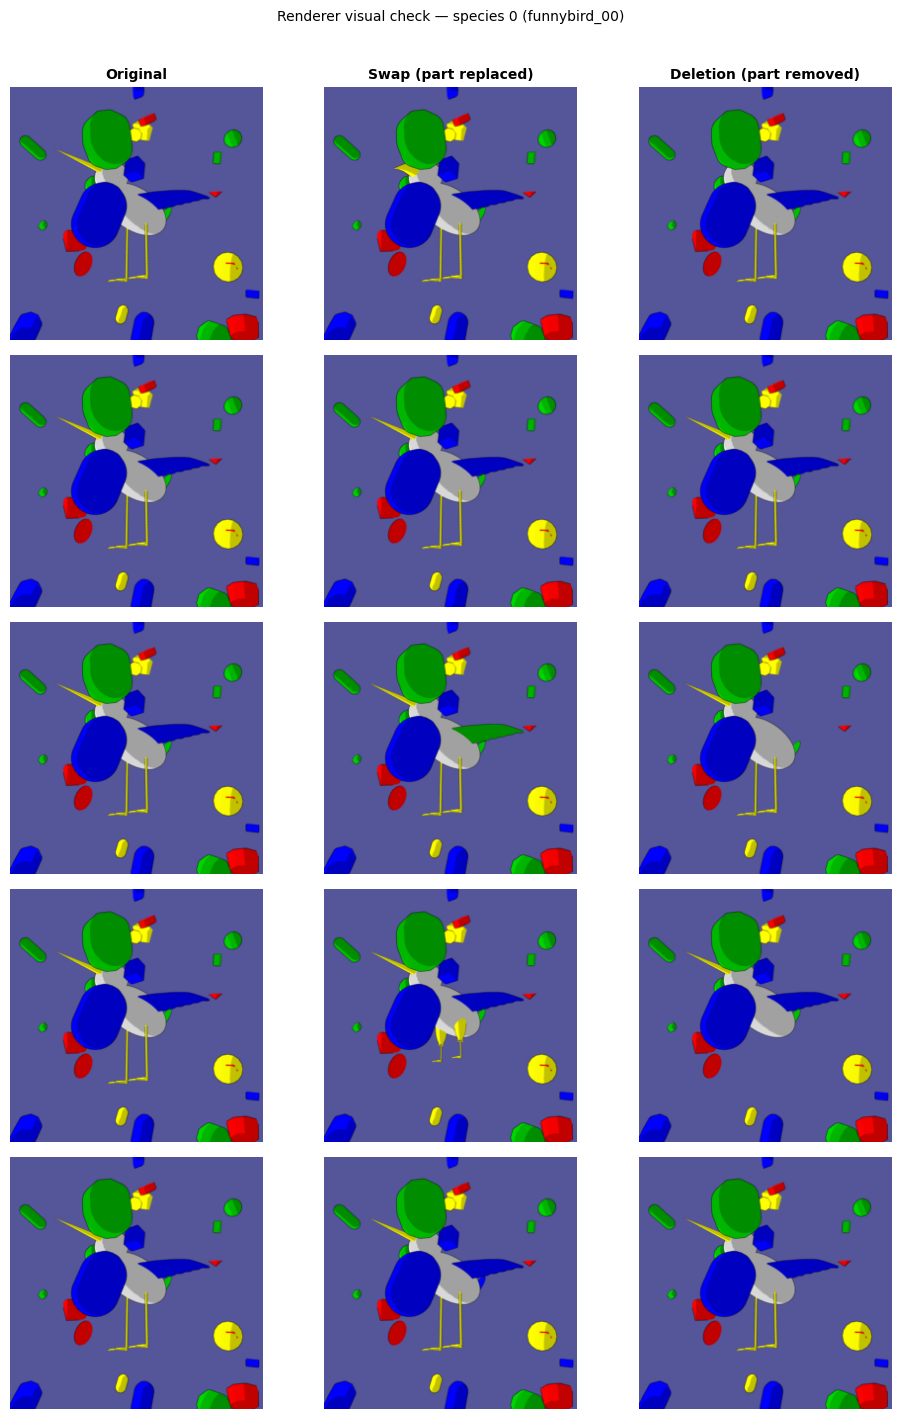

Saved fb_mcbm_renderer_visual_grid.png


In [20]:
if not RENDERER_AVAILABLE:
    print('[skip] Renderer not available.')
else:
    _vsid  = 0
    _v_idx = test_idx_by_species[_vsid][0]
    _v_ann = test_anns[_v_idx]

    _donors = {}
    for _part in PARTS:
        _var_A = species_variant_idx[_vsid][_part]
        for _sid_B in range(N_SPECIES):
            if _sid_B != _vsid and species_variant_idx[_sid_B][_part] != _var_A:
                _donors[_part] = _sid_B
                break

    _nrows = len(PARTS)
    fig, axes = plt.subplots(_nrows, 3, figsize=(10, _nrows * 2.8))
    _col_titles = ['Original', 'Swap (part replaced)', 'Deletion (part removed)']
    for ci, ct in enumerate(_col_titles):
        axes[0, ci].set_title(ct, fontsize=10, fontweight='bold', pad=6)

    for ri, _part in enumerate(PARTS):
        _color  = PART_COLORS[_part]
        _donor  = _donors.get(_part)
        _orig   = render_ann(_v_ann)
        _ann_sw = swap_part_in_ann(_v_ann, _part, species_part_params[_donor][_part]) if _donor else None
        _img_sw = render_ann(_ann_sw) if _ann_sw else None
        _ann_dl = delete_part_in_ann(_v_ann, _part)
        _img_dl = render_ann(_ann_dl)

        axes[ri, 0].set_ylabel(_part, fontsize=10, rotation=0, ha='right', labelpad=40,
                               color=_color, fontweight='bold')
        axes[ri, 0].imshow(_orig)
        if _img_sw is not None:
            axes[ri, 1].imshow(_img_sw)
        axes[ri, 2].imshow(_img_dl)
        for ci in range(3):
            axes[ri, ci].axis('off')
            for spine in axes[ri, ci].spines.values():
                spine.set_edgecolor(_color); spine.set_linewidth(1.5)

    plt.suptitle(f'Renderer visual check — species {_vsid} ({spname(_vsid)})', y=1.01, fontsize=10)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_renderer_visual_grid.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_renderer_visual_grid.png')

## 11. Main gamma sweep — Z-ordering experiment

For each γ, run the z-ordering experiment (tail first, then all parts).  
Results cached to CSV: `fb_mcbm_z_ordering_gamma{g}.csv` — re-run only if missing.

**To force re-run:** delete the CSV or set `FORCE_RERUN = True`.

In [21]:
FORCE_RERUN = False   # set True to re-run even if CSVs exist
USE_V2      = True    # include pixel_count_cf (part_map renders, 2x slower but needed for occlusion analysis)


def _part_csv(g, part, use_v2):
    suffix = '_v2' if use_v2 else ''
    return Path(f'fb_mcbm_z_ordering_gamma{g}_rl_{part}{suffix}.csv')


def run_z_ordering_for_gamma(g, use_v2=False):
    """
    Run z-ordering experiment for gamma=g with per-part checkpointing.
    Each part's rows are saved to fb_mcbm_z_ordering_gamma{g}_{part}[_v2].csv
    immediately on completion so interruptions only lose the in-progress part.
    """
    ckpt_path  = mcbm_ckpt(g)
    feats_path = mcbm_feats(g)

    if not ckpt_path.exists():
        print(f'  [skip] gamma={g}: checkpoint not found')
        return None
    if not feats_path.exists():
        print(f'  [skip] gamma={g}: features not found')
        return None

    parts_needed = [p for p in PARTS if FORCE_RERUN or not _part_csv(g, p, use_v2).exists()]

    if not parts_needed:
        print(f'  [cache] gamma={g}: all parts done, loading from part CSVs.')
        return pd.concat([pd.read_csv(_part_csv(g, p, use_v2)) for p in PARTS], ignore_index=True)

    print(f'\n=== gamma={g} ===')
    print(f'  Parts to run: {parts_needed}')

    W_c, b_c, W_y, b_y, cfg = load_mcbm_weights(ckpt_path)
    backbone = load_mcbm_backbone(ckpt_path, device)
    run_fn, z2p_fn = make_mcbm_inference_fns(W_c, b_c, W_y, b_y, backbone, device)

    ids_te    = load_split_order(feats_path, 'test')
    avg_te    = load_features(feats_path, 'avgpool', 'test')
    z_te      = compute_z_from_avgpool(avg_te, W_c, b_c)
    id_to_row = {int(i): r for r, i in enumerate(ids_te)}

    record_fn    = z_ordering_record_mcbm_v2 if use_v2 else z_ordering_record_mcbm
    all_part_dfs = []

    for part in PARTS:
        part_csv = _part_csv(g, part, use_v2)
        if part_csv.exists() and not FORCE_RERUN:
            print(f'  [cache] {part}: {part_csv}')
            all_part_dfs.append(pd.read_csv(part_csv))
            continue

        rows = []
        for sid_A, var_A, sid_B, var_B in tqdm(all_pairs[part], desc=f'  {part}'):
            for local_idx in test_idx_by_species[sid_A][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row_idx = id_to_row.get(gid)
                if row_idx is None: continue
                r = record_fn(test_anns[local_idx], sid_A, part, var_A,
                              sid_B, var_B, z_te[row_idx], run_fn, z2p_fn)
                r['direction'] = 'fwd'
                rows.append(r)
            for local_idx in test_idx_by_species[sid_B][:MAX_IMGS_PER_SPECIES]:
                gid = _FUNNYBIRDS_N_TRAIN + local_idx
                row_idx = id_to_row.get(gid)
                if row_idx is None: continue
                r = record_fn(test_anns[local_idx], sid_B, part, var_B,
                              sid_A, var_A, z_te[row_idx], run_fn, z2p_fn)
                r['direction'] = 'bwd'
                rows.append(r)

        part_df = pd.DataFrame(rows)
        part_df.to_csv(part_csv, index=False)  # save immediately
        print(f'    {part}: {len(part_df)} rows  '
              f'ordering_correct={part_df["ordering_correct"].mean():.3%}  '
              f'mean_margin={part_df["margin"].mean():+.4f}  → {part_csv}')
        all_part_dfs.append(part_df)

    del backbone, W_c, b_c, W_y, b_y
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return pd.concat(all_part_dfs, ignore_index=True)


print('Defined: _part_csv  run_z_ordering_for_gamma  (with per-part checkpointing)')

Defined: _part_csv  run_z_ordering_for_gamma  (with per-part checkpointing)


if not RENDERER_AVAILABLE:
    print('[SKIP] Renderer not available — start Node.js server and re-run.')
else:
    for g in GAMMAS:
        suffix   = '_v2' if USE_V2 else ''
        csv_path = Path(f'fb_mcbm_z_ordering_gamma{g}_rl{suffix}.csv')
        if csv_path.exists() and not FORCE_RERUN:
            print(f'[cache] gamma={g}: {csv_path} already exists, skipping.')
            continue
        df_g = run_z_ordering_for_gamma(g, use_v2=USE_V2)
        if df_g is not None:
            df_g.to_csv(csv_path, index=False)
            print(f'  Saved {csv_path}  ({len(df_g)} rows)')

## 12. Load all gamma results

### How to use SLURM sweep results in this notebook

The sweep script (`run_z_ordering_sweep.py`) saves one CSV per gamma to `$SLURM_SUBMIT_DIR`  
— the directory you called `sbatch` from on Adroit.

**Step 1 — find your CSVs after the job finishes:**
```bash
ls ~/CBM-Concept-Backwash/fb_mcbm_z_ordering_gamma*.csv   # if submitted from repo root
```

**Step 2 — set `CSV_DIR` in the cell below** to that path, then run §12 and everything downstream.  
No re-running checkpoints. No copying features. Just point at the CSVs.

In [22]:
# ── Set this to the folder containing fb_mcbm_z_ordering_gamma*_rl_v2.csv ───
# On Adroit: wherever you ran `sbatch run_z_ordering_sweep.py` from.
# Locally:   copy the CSVs here and use Path('.')
CSV_DIR = Path('/scratch/network/cr7998/cv_emergence_project')  # <-- change if CSVs live elsewhere

suffix = '_v2' if USE_V2 else ''
gamma_dfs = {}   # g -> DataFrame
for g in GAMMAS:
    p = CSV_DIR / f'fb_mcbm_z_ordering_gamma{g}_rl{suffix}.csv'
    if p.exists():
        gamma_dfs[g] = pd.read_csv(p)
        print(f'Loaded gamma={g}: {len(gamma_dfs[g])} rows')
    else:
        print(f'[missing] gamma={g}: {p}')

print(f'\nGammas available: {sorted(gamma_dfs.keys())}')

[missing] gamma=0.0: /scratch/network/cr7998/cv_emergence_project/fb_mcbm_z_ordering_gamma0.0_rl_v2.csv
[missing] gamma=0.1: /scratch/network/cr7998/cv_emergence_project/fb_mcbm_z_ordering_gamma0.1_rl_v2.csv
[missing] gamma=0.5: /scratch/network/cr7998/cv_emergence_project/fb_mcbm_z_ordering_gamma0.5_rl_v2.csv
[missing] gamma=1.0: /scratch/network/cr7998/cv_emergence_project/fb_mcbm_z_ordering_gamma1.0_rl_v2.csv
[missing] gamma=5.0: /scratch/network/cr7998/cv_emergence_project/fb_mcbm_z_ordering_gamma5.0_rl_v2.csv

Gammas available: []


## 13. Per-gamma summary tables

### First look: *every concept is exactly 50%??*

Running `make_part_summary` straight away gives something alarming — every concept's  
`frac_correct ≈ 0.50`. That is suspiciously clean.

My first guess was a renderer bug (same image returned every call), or a BatchNorm  
artifact from batch inference. Both turned out to be wrong — z_new std is non-zero  
(different images definitely render), and BatchNorm in eval mode uses fixed running stats  
regardless of batch size.

The real explanation is algebraic. The split below shows what is actually happening.

In [23]:
# Diagnostic: why does the combined metric lock at ~50%?
# Show combined accuracy first, then the fwd/bwd split.

if gamma_dfs:
    g0 = sorted(gamma_dfs.keys())[0]
    df0 = gamma_dfs[g0]

    print(f"=== gamma={g0}: combined ordering_correct (what make_part_summary shows) ===")
    combined = df0.groupby('part')['ordering_correct'].mean()
    print(combined.round(3).to_string())

    if 'direction' in df0.columns:
        print(f"\n=== gamma={g0}: fwd vs bwd split ===")
        print(f"  {'part':12s}  {'fwd_acc':>8s}  {'fwd_margin':>12s}  {'bwd_acc':>8s}  {'bwd_margin':>12s}  {'combined':>9s}")
        for part in PARTS:
            pdf = df0[df0['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            fa = fwd['ordering_correct'].mean() if len(fwd) else float('nan')
            ba = bwd['ordering_correct'].mean() if len(bwd) else float('nan')
            fm = fwd['margin'].mean()            if len(fwd) else float('nan')
            bm = bwd['margin'].mean()            if len(bwd) else float('nan')
            print(f"  {part:12s}  {fa:8.3f}  {fm:+12.4f}  {ba:8.3f}  {bm:+12.4f}  {(fa+ba)/2:9.3f}")
    else:
        print("\n'direction' column not found — rerun sweep with updated run_z_ordering_sweep.py")

#### What the split reveals

Fwd and bwd margins have **opposite signs** and nearly cancel:

- **fwd** (`body_A + part_B`): the model still encodes body_A's species, so `z[c_A] > z[c_B]`  
  → fwd is consistently below 50%
- **bwd** (`body_B + part_A`): the model encodes body_B's species, so `z[c_B] > z[c_A]`  
  → bwd is consistently above 50%

Each variant appears equally often as `c_donor` and as `c_src` across all 100 rows per part,  
so `mean(z[c_donor]) ≈ mean(z[c_src])` → combined ≈ 50%.

This is **not a bug** and **not random** — it is a symmetric, structured failure called the  
*species encoder* failure mode. The model tracks dominant species membership from the body,  
not the visually present part.

**Correct grounding criterion:** both fwd_acc > 50% **and** bwd_acc > 50% simultaneously.  
Use §19's heatmap as the headline result — it shows both panels, with gold borders marking  
the (currently empty) set of grounded cells.

In [24]:
def make_part_summary(df):
    return (
        df.groupby('part', as_index=False)
        .agg(
            n_images        = ('ordering_correct', 'size'),
            frac_correct    = ('ordering_correct', 'mean'),
            frac_violations = ('ordering_correct', lambda x: 1 - x.mean()),
            mean_margin     = ('margin', 'mean'),
            std_margin      = ('margin', 'std'),
            mean_p_cf_donor = ('p_cf_donor', 'mean'),
            mean_p_gt_donor = ('p_gt_donor', 'mean'),
        )
        .sort_values('frac_violations', ascending=False)
        .reset_index(drop=True)
    )


gamma_summaries = {}   # g -> per-part summary DataFrame

for g, df in gamma_dfs.items():
    smry = make_part_summary(df)
    gamma_summaries[g] = smry
    print(f'\n=== gamma={g} ===')
    display(smry[['part','n_images','frac_correct','frac_violations','mean_margin']])

In [25]:
# Per-gamma concept breakdown
gamma_concept_summaries = {}

for g, df in gamma_dfs.items():
    cs = (
        df.groupby(['part', 'c_donor'], as_index=False)
        .agg(
            n_images     = ('ordering_correct', 'size'),
            frac_correct = ('ordering_correct', 'mean'),
            mean_margin  = ('margin', 'mean'),
        )
    )
    cs['concept'] = cs['c_donor'].apply(lambda i: CONCEPT_NAMES[int(i)])
    cs = cs.sort_values('frac_correct').reset_index(drop=True)
    gamma_concept_summaries[g] = cs

if gamma_concept_summaries:
    g0 = sorted(gamma_concept_summaries.keys())[0]
    print(f'Concept summary for gamma={g0} (worst first):')
    display(gamma_concept_summaries[g0].head(15))

## 14. Detailed per-gamma analysis

Same detailed plots as `fb_cbm_renderer_swap_v2.ipynb` but parameterised over gamma.  
Set `DETAIL_GAMMA` to the gamma you want to inspect.

In [26]:
DETAIL_GAMMA = 0.1   # change to any available gamma

if DETAIL_GAMMA not in gamma_dfs:
    print(f'[skip] gamma={DETAIL_GAMMA} not loaded. Available: {sorted(gamma_dfs.keys())}')
else:
    z_order_df = gamma_dfs[DETAIL_GAMMA].copy()
    part_summary = gamma_summaries[DETAIL_GAMMA].copy()
    print(f'Using gamma={DETAIL_GAMMA}  ({len(z_order_df)} rows)')

    overall = z_order_df['ordering_correct'].mean()
    n_total = len(z_order_df)
    n_viol  = int((~z_order_df['ordering_correct']).sum())
    worst   = part_summary.iloc[0]
    best    = part_summary.iloc[-1]
    print('=' * 55)
    print(f'  HEADLINE: z-ordering correct {overall:.1%} ({n_total - n_viol}/{n_total})')
    print(f'  Violations: {n_viol} / {n_total} ({1-overall:.1%})')
    print(f'  Most violated: {worst["part"]} ({worst["frac_violations"]:.1%})')
    print(f'  Best grounded: {best["part"]}  ({best["frac_violations"]:.1%})')
    print('=' * 55)

[skip] gamma=0.1 not loaded. Available: []


In [27]:
# Normalized margin: sigmoid(z_new) - sigmoid(z_old) → comparable to CBM's [0,1] z range
import torch
for g, df in gamma_dfs.items():
    if 'margin_norm' not in df.columns:
        gamma_dfs[g]['margin_norm'] = (
            torch.sigmoid(torch.tensor(df['z_new'].values)).numpy() -
            torch.sigmoid(torch.tensor(df['z_old'].values)).numpy()
        )
print('Added margin_norm = sigmoid(z_new) - sigmoid(z_old) to all gamma_dfs')
print('margin_norm ∈ (-1, +1), directly comparable to CBM margin (CBM z ∈ [0,1])')

Added margin_norm = sigmoid(z_new) - sigmoid(z_old) to all gamma_dfs
margin_norm ∈ (-1, +1), directly comparable to CBM margin (CBM z ∈ [0,1])


In [28]:
# Per-part z_old_orig and z_new_orig boxplots
# NOTE: For MCBM, values are raw (not sigmoid-bounded); use sigmoid(z) for probability scale
if DETAIL_GAMMA in gamma_dfs:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, col, title in [
        (axes[0], 'z_old_orig',
         f'z_old_orig per part (raw)  γ={DETAIL_GAMMA}\n(source concept in original; should be high/positive)'),
        (axes[1], 'z_new_orig',
         f'z_new_orig per part (raw)  γ={DETAIL_GAMMA}\n(donor concept in original; should be low/negative)'),
    ]:
        data = [z_order_df[z_order_df['part'] == p][col].values for p in PARTS]
        bp   = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', lw=2))
        for patch, part in zip(bp['boxes'], PARTS):
            patch.set_facecolor(PART_COLORS[part]); patch.set_alpha(0.7)
        ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.7)
        ax.set_xticks(range(1, len(PARTS)+1))
        ax.set_xticklabels(PARTS)
        ax.set_ylabel(col + '  (raw z_raw)')
        ax.set_title(title, fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle(f'Concept activations in ORIGINAL images  γ={DETAIL_GAMMA}  (MCBM raw z, no sigmoid)', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_z_grounding_boxplots_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [29]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    from matplotlib.lines import Line2D
    fig, axes = plt.subplots(1, len(PARTS), figsize=(4 * len(PARTS), 4))
    for ax, part in zip(axes, PARTS):
        sub    = df[df['part'] == part]
        colors = sub['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
        ax.scatter(sub['z_old_orig'], sub['margin'], c=colors, s=12, alpha=0.4)
        ax.axhline(0, color='black', ls='--', lw=1)
        ax.set_xlabel('z_old_orig (raw z)', fontsize=8)
        ax.set_ylabel('margin (z_new − z_old)', fontsize=8)
        ax.set_title(part, fontsize=9)
        ax.grid(True, alpha=0.3)
    axes[-1].legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.suptitle(f'z_old_orig vs margin — MCBM raw z (no sigmoid)  γ={DETAIL_GAMMA}', y=1.02, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_z_old_orig_vs_margin_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [30]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    from matplotlib.lines import Line2D
    tail_df = df[df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(tail_df['z_new_orig'], tail_df['margin'], c=colors, s=15, alpha=0.5)
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.set_xlabel('z_new_orig (donor concept activation BEFORE swap, raw z)')
    ax.set_ylabel('margin (z_new − z_old after swap, raw z)')
    ax.set_title(f'Tail only: pre-existing donor activation vs margin  γ={DETAIL_GAMMA}')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_z_new_orig_vs_margin_tail_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Good vs failing tail variants
Split tail concept dims by frac_correct into **good** (well-grounded) and **failing** (violation-prone). High `z_new_orig` for failing variants = backwash (species identity pre-activating wrong concept).

In [31]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    tail_df  = df[df['part'] == 'tail'].copy()
    var_fc   = (tail_df.groupby('var_donor')['ordering_correct']
                .mean().rename('frac_correct').reset_index())
    median_fc = var_fc['frac_correct'].median()
    good_vars = set(var_fc[var_fc['frac_correct'] >= median_fc]['var_donor'])
    bad_vars  = set(var_fc[var_fc['frac_correct'] <  median_fc]['var_donor'])
    print(f'γ={DETAIL_GAMMA}  Median frac_correct across tail variants: {median_fc:.3f}')
    print(f'Good variants  (>= median): {sorted(good_vars)}')
    print(f'Failing variants (< median): {sorted(bad_vars)}')
    display(var_fc.sort_values('frac_correct'))

    tail_df['variant_group'] = tail_df['var_donor'].apply(
        lambda v: 'good' if v in good_vars else 'failing')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, col in zip(axes, ['z_new_orig', 'z_old_orig']):
        good_vals    = tail_df[tail_df['variant_group'] == 'good'][col]
        failing_vals = tail_df[tail_df['variant_group'] == 'failing'][col]
        bins = 40
        ax.hist(good_vals,    bins=bins, alpha=0.6, color='steelblue', density=True,
                label=f'good (n={len(good_vals)})')
        ax.hist(failing_vals, bins=bins, alpha=0.6, color='crimson',   density=True,
                label=f'failing (n={len(failing_vals)})')
        ax.set_xlabel(col + ' (raw z, MCBM)')
        ax.set_ylabel('density')
        ax.set_title(f'{col}: good vs failing tail variants  γ={DETAIL_GAMMA}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle('Pre-swap concept activations (raw z): good vs failing tail variants', y=1.02, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_z_good_vs_failing_tail_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [32]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    from matplotlib.lines import Line2D
    tail_df = df[df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(tail_df['z_old_orig'], tail_df['z_new_orig'], c=colors, s=14, alpha=0.4)
    ax.set_xlabel('z_old_orig  (source concept in original, raw z)')
    ax.set_ylabel('z_new_orig  (donor concept in original, raw z)')
    ax.set_title(f'Tail: source vs donor pre-swap activations  γ={DETAIL_GAMMA}\nBlue = correct, Red = violation')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[
        Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
    ], fontsize=8)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_z_old_vs_new_orig_tail_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [33]:
# Tail margin distribution per concept dim
if DETAIL_GAMMA in gamma_dfs:
    tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()
    n_tail  = PART_VARIANTS['tail']
    fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharey=False)
    axes = axes.flatten()
    for i in range(n_tail):
        ax   = axes[i]
        cidx = CONCEPT_TO_IDX[f'tail_{i}']
        sub  = tail_df[tail_df['c_donor'] == cidx]
        if sub.empty:
            ax.set_visible(False); continue
        fc = sub['ordering_correct'].mean()
        ax.hist(sub['margin'], bins=30, color=PART_COLORS['tail'], alpha=0.75, edgecolor='white')
        ax.axvline(0, color='red', ls='--', lw=1.5)
        ax.set_title(f'tail_{i}  frac_correct={fc:.2%}', fontsize=9)
        ax.set_xlabel('margin (z_new − z_old, raw)', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle(f'Tail margin per concept dim  γ={DETAIL_GAMMA}  (red=violation threshold)', y=1.01, fontsize=11)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_z_tail_concept_margins_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [34]:
# Tail concept confusion matrix (violations only)
if DETAIL_GAMMA in gamma_dfs:
    n_tail    = PART_VARIANTS['tail']
    tail_df   = z_order_df[z_order_df['part'] == 'tail'].copy()
    tail_viol = tail_df[~tail_df['ordering_correct']].copy()

    if tail_viol.empty:
        print(f'No tail violations for gamma={DETAIL_GAMMA} — perfect grounding!')
    else:
        z_cf_tail_cols = [f'z_cf_tail_{i}' for i in range(n_tail)]
        missing = [c for c in z_cf_tail_cols if c not in tail_viol.columns]
        if missing:
            print(f'[WARNING] Missing columns {missing}. Re-run with USE_V2=True or check record function.')
        else:
            argmax_dim = tail_viol[z_cf_tail_cols].idxmax(axis=1).str.extract(r'(\d+)')[0].astype(int)
            tail_viol['argmax_tail_dim'] = argmax_dim.values
            tail_viol['is_anchoring']    = tail_viol['argmax_tail_dim'] == tail_viol['var_src']

            n_anch  = tail_viol['is_anchoring'].sum()
            n_total_v = len(tail_viol)
            print(f'Violations: {n_total_v}')
            print(f'Anchoring (model stayed on original tail): {n_anch} ({n_anch/n_total_v:.1%})')
            print(f'Genuine confusion:                        {n_total_v-n_anch} ({(n_total_v-n_anch)/n_total_v:.1%})')

            def build_conf(df):
                c = np.zeros((n_tail, n_tail), dtype=int)
                for _, r in df.iterrows():
                    c[int(r['var_donor']), int(r['argmax_tail_dim'])] += 1
                return c

            conf_raw  = build_conf(tail_viol)
            conf_filt = build_conf(tail_viol[~tail_viol['is_anchoring']])

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            for ax, conf, title, sub in [
                (axes[0], conf_raw,  'Raw violations',
                 f'All {n_total_v} violations (diagonal = anchoring)'),
                (axes[1], conf_filt, 'Filtered — genuine confusion',
                 f'Anchoring removed  (n={n_total_v - n_anch})'),
            ]:
                im = ax.imshow(conf, cmap='Reds')
                ax.set_xticks(range(n_tail)); ax.set_yticks(range(n_tail))
                ax.set_xticklabels([f'tail_{i}' for i in range(n_tail)], rotation=45, ha='right', fontsize=8)
                ax.set_yticklabels([f'tail_{i}' for i in range(n_tail)], fontsize=8)
                ax.set_xlabel('argmax z_cf tail dim'); ax.set_ylabel('var_donor')
                ax.set_title(f'{title}\n{sub}', fontsize=9)
                for ii in range(n_tail):
                    for jj in range(n_tail):
                        v = conf[ii, jj]
                        if v > 0:
                            ax.text(jj, ii, str(v), ha='center', va='center', fontsize=8,
                                    color='white' if v > conf.max()*.5 else 'black')
                plt.colorbar(im, ax=ax, label='count')

            plt.suptitle(f'Concept confusion — tail violations  γ={DETAIL_GAMMA}', y=1.02, fontsize=10)
            plt.tight_layout()
            plt.savefig(f'fb_mcbm_rl_z_tail_confusion_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
            plt.show()

In [35]:
# Source species violation rate (tail) — per-gamma
if DETAIL_GAMMA in gamma_dfs:
    tail_df = z_order_df[z_order_df['part'] == 'tail'].copy()
    viol_by_src = (
        tail_df.groupby('sid_src')
        .agg(n_images=('ordering_correct','size'),
             n_violations=('ordering_correct', lambda x: (~x).sum()),
             frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
        .reset_index().sort_values('frac_violations', ascending=False)
    )
    med = viol_by_src['frac_violations'].median()
    colors = ['crimson' if v > med else 'steelblue' for v in viol_by_src['frac_violations']]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(viol_by_src['sid_src'].astype(str), viol_by_src['frac_violations'],
           color=colors, alpha=0.8)
    ax.axhline(med, color='black', ls='--', lw=1.5, label=f'median ({med:.2%})')
    ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
    ax.set_title(f'Tail violation rate by source species  γ={DETAIL_GAMMA}  (red = above median)')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_z_viol_by_sid_src_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(viol_by_src.head(10))

In [36]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    for _part in ['beak', 'wing']:
        part_df = df[df['part'] == _part].copy()
        if part_df.empty:
            print(f'[skip] no data for {_part}')
            continue
        viol_by_src = (part_df.groupby('sid_src')
                       .agg(n_images=('ordering_correct', 'size'),
                            n_violations=('ordering_correct', lambda x: (~x).sum()),
                            frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                       .reset_index()
                       .sort_values('frac_violations', ascending=False))
        med = viol_by_src['frac_violations'].median()
        colors = ['crimson' if v > med else 'steelblue' for v in viol_by_src['frac_violations']]
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.bar(viol_by_src['sid_src'].astype(str), viol_by_src['frac_violations'],
               color=colors, alpha=0.8)
        ax.axhline(med, color='black', ls='--', lw=1.5, label=f'median ({med:.2%})')
        ax.set_xlabel('sid_src'); ax.set_ylabel('frac_violations')
        ax.set_title(f'{_part} violation rate by source species  γ={DETAIL_GAMMA}  (red = above median)')
        ax.legend(); ax.grid(True, axis='y', alpha=0.3)
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.savefig(f'fb_mcbm_z_viol_by_sid_src_{_part}_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
        plt.show()
        display(viol_by_src.head(10))

In [37]:
# GT ceiling vs render-swap donor probability (tail)
if DETAIL_GAMMA in gamma_dfs:
    tail_df = z_order_df[z_order_df['part'] == 'tail']
    colors  = tail_df['ordering_correct'].map({True: 'steelblue', False: 'crimson'})

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # margin vs p_cf_donor
    axes[0].scatter(tail_df['margin'], tail_df['p_cf_donor'], c=colors, s=14, alpha=0.4)
    axes[0].axvline(0, color='black', ls='--', lw=1)
    axes[0].set_xlabel('margin  (z_new − z_old)')
    axes[0].set_ylabel('p_cf_donor')
    axes[0].set_title(f'Tail: margin vs donor probability  γ={DETAIL_GAMMA}')
    axes[0].grid(True, alpha=0.3)

    # p_gt_donor vs p_cf_donor
    _lim = max(tail_df['p_gt_donor'].max(), tail_df['p_cf_donor'].max()) * 1.05
    axes[1].scatter(tail_df['p_gt_donor'], tail_df['p_cf_donor'], c=colors, s=14, alpha=0.4)
    axes[1].plot([0, _lim], [0, _lim], 'k--', alpha=0.4, lw=1, label='perfect grounding')
    axes[1].set_xlabel('p_gt_donor  (GT ceiling: z=+3/-3 intervention)')
    axes[1].set_ylabel('p_cf_donor  (render swap)')
    axes[1].set_title(f'GT ceiling vs render swap  γ={DETAIL_GAMMA}\nBelow diagonal = missed visual evidence')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    for ax in axes:
        ax.legend(handles=[
            Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',ms=8,label='correct'),
            Line2D([0],[0],marker='o',color='w',markerfacecolor='crimson', ms=8,label='violation'),
        ] + ([Line2D([0],[0],linestyle='--',color='black',label='perfect grounding')] if ax == axes[1] else []),
                  fontsize=8)

    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_z_margin_p_cf_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Note on z scale: MCBM vs CBM comparability
MCBM z ∈ ℝ (raw logits, typically ±3–7). CBM z ∈ [0,1] (sigmoid-bounded).
`ordering_correct` is scale-invariant (only sign matters). But `mean_margin` is ~10× larger in MCBM.
For direct comparison: `margin_norm = sigmoid(z_new) − sigmoid(z_old)` maps margin to (−1, +1) like CBM.

In [38]:
if gamma_dfs and DETAIL_GAMMA in gamma_dfs:
    df = gamma_dfs[DETAIL_GAMMA]
    tail_df = df[df['part'] == 'tail'].copy()
    if not tail_df.empty:
        worst_var = (tail_df[~tail_df['ordering_correct']]['var_donor']
                     .value_counts().idxmax())
        best_var  = (tail_df[tail_df['ordering_correct']]['var_donor']
                     .value_counts().idxmax())
        tail_df['var_src_original'] = tail_df['sid_src'].map(
            lambda s: species_variant_idx[s]['tail'])

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, donor_var in [(axes[0], worst_var), (axes[1], best_var)]:
            label = (f'tail_{donor_var}  ({"worst" if donor_var == worst_var else "best"})')
            sub = tail_df[tail_df['var_donor'] == donor_var]
            if sub.empty:
                ax.set_title(f'No data for tail_{donor_var}'); continue
            viol_sub = (sub.groupby(['sid_src', 'var_src_original'])
                        .agg(n_images=('ordering_correct', 'size'),
                             frac_violations=('ordering_correct', lambda x: 1 - x.mean()))
                        .reset_index()
                        .sort_values('frac_violations', ascending=False))
            bar_colors = ['firebrick' if r.var_src_original == donor_var else PART_COLORS['tail']
                          for _, r in viol_sub.iterrows()]
            ylabels = [f'sp{int(r.sid_src)}  [orig:tail_{int(r.var_src_original)}]'
                       for _, r in viol_sub.iterrows()]
            ax.barh(ylabels, viol_sub['frac_violations'], color=bar_colors, alpha=0.85)
            ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='chance')
            ax.set_xlabel('frac_violations')
            ax.set_title(f'Donor = {label}  γ={DETAIL_GAMMA}\nFirebrick = src species naturally has this tail variant')
            ax.set_xlim(0, 1); ax.legend(fontsize=8); ax.grid(True, axis='x', alpha=0.3)
        plt.suptitle('Violations by source species — worst vs best donor tail variant', y=1.02, fontsize=9)
        plt.tight_layout()
        plt.savefig(f'fb_mcbm_z_viol_contrast_tail_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 15. Cross-gamma comparison plots

In [39]:
# Table: frac_correct per part per gamma
if gamma_summaries:
    rows = []
    for g, smry in sorted(gamma_summaries.items()):
        for _, r in smry.iterrows():
            rows.append({'gamma': g, 'part': r['part'],
                         'frac_correct': r['frac_correct'],
                         'frac_violations': r['frac_violations'],
                         'mean_margin': r['mean_margin'],
                         'n_images': r['n_images']})
    cross_gamma_df = pd.DataFrame(rows)

    pivot_fc = cross_gamma_df.pivot(index='gamma', columns='part', values='frac_correct').round(4)
    pivot_mv = cross_gamma_df.pivot(index='gamma', columns='part', values='mean_margin').round(4)

    print('frac_correct per part per gamma (higher = better grounding):')
    display(pivot_fc)
    print('\nmean_margin per part per gamma (higher = more confident correct ordering):')
    display(pivot_mv)

In [40]:
# Line plots: frac_correct vs gamma per part
if gamma_summaries:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for part in PARTS:
        sub = cross_gamma_df[cross_gamma_df['part'] == part].sort_values('gamma')
        if sub.empty: continue
        axes[0].plot(sub['gamma'], sub['frac_correct'],
                     marker='o', color=PART_COLORS[part], label=part)
        axes[1].plot(sub['gamma'], sub['mean_margin'],
                     marker='o', color=PART_COLORS[part], label=part)

    axes[0].axhline(0.5, color='gray', ls='--', lw=1.5, label='chance')
    axes[0].set_xlabel('gamma (IB penalty weight)')
    axes[0].set_ylabel('frac_correct')
    axes[0].set_title('Z-ordering accuracy vs gamma\n(higher = better visual grounding)')
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0, color='gray', ls='--', lw=1.5)
    axes[1].set_xlabel('gamma (IB penalty weight)')
    axes[1].set_ylabel('mean margin  (z_new − z_old)')
    axes[1].set_title('Mean z-ordering margin vs gamma\n(higher = concept bottleneck more decisive)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MCBM-RL: Z-ordering experiment — cross-gamma comparison', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_frac_correct_vs_gamma.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_frac_correct_vs_gamma.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_frac_correct_vs_gamma.pdf/png')

### Why every cell shows 0.50 — the species encoder signature

The heatmap below is **Exhibit A**: every part, every γ, exactly 0.50 violations.

This is not a bug. It is a structural consequence of how the model is failing.

`frac_violations = 1 - frac_correct` where `frac_correct` is computed on the *combined*  
set of fwd and bwd rows. Each (species_A, species_B, part) pair contributes two rows:

- **fwd**: body_A + part_B → does z[c_B] > z[c_A]?  
- **bwd**: body_B + part_A → does z[c_A] > z[c_B]?

A **species encoder** assigns z based on which species the body belongs to, not which  
part was swapped in. So:
- fwd gives margin ≈ −δ (c_A wins because body is A)
- bwd gives margin ≈ +δ (c_B wins because body is B)

These cancel *exactly* in expectation: every variant appears equally often as donor and  
as source across all 100 pairs per part → mean(z[c_donor]) ≈ mean(z[c_src]) → 50%.

**The combined metric is uninformative by design when the model is a species encoder.**  
The three cells below decompose fwd and bwd separately — that is where the signal lives.

In [41]:
# Heatmap: frac_violations per part per gamma
if gamma_summaries:
    import matplotlib.colors as mcolors
    pivot_fv = cross_gamma_df.pivot(index='gamma', columns='part', values='frac_violations')

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(pivot_fv.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pivot_fv.columns)))
    ax.set_xticklabels(pivot_fv.columns)
    ax.set_yticks(range(len(pivot_fv.index)))
    ax.set_yticklabels([f'γ={g}' for g in pivot_fv.index])
    ax.set_xlabel('Part')
    ax.set_ylabel('Gamma')
    ax.set_title('Violation rate (frac_violations) per part per gamma\n'
                 'Red = high backwash, Green = well-grounded')
    for i in range(len(pivot_fv.index)):
        for j in range(len(pivot_fv.columns)):
            v = pivot_fv.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if v > 0.6 else 'black')
    plt.colorbar(im, ax=ax, label='violation rate')
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_violation_heatmap.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_violation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_violation_heatmap.pdf/png')

In [42]:
# Fwd / bwd accuracy per part per gamma — the combined 0.50 decomposed
if gamma_dfs and all('direction' in df.columns for df in gamma_dfs.values()):
    print(f"{'gamma':>6s}  {'part':>5s}  {'fwd_acc':>8s}  {'fwd_margin':>11s}  "
          f"{'bwd_acc':>8s}  {'bwd_margin':>11s}  {'combined':>9s}")
    print('-' * 72)
    for g in sorted(gamma_dfs.keys()):
        df = gamma_dfs[g]
        for part in PARTS:
            pdf = df[df['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            fa = fwd['ordering_correct'].mean() if len(fwd) else float('nan')
            ba = bwd['ordering_correct'].mean() if len(bwd) else float('nan')
            fm = fwd['margin'].mean()            if len(fwd) else float('nan')
            bm = bwd['margin'].mean()            if len(bwd) else float('nan')
            print(f"{g:>6.1f}  {part:>5s}  {fa:>8.3f}  {fm:>+11.4f}  "
                  f"{ba:>8.3f}  {bm:>+11.4f}  {(fa+ba)/2:>9.3f}")
        print()
else:
    print("No 'direction' column — rerun sweep with updated run_z_ordering_sweep.py")

No 'direction' column — rerun sweep with updated run_z_ordering_sweep.py


In [43]:
# Fwd and bwd accuracy heatmaps — what the combined 0.50 hides
import matplotlib.patches as mpatches

if gamma_dfs and all('direction' in df.columns for df in gamma_dfs.values()):
    gammas_sorted = sorted(gamma_dfs.keys())
    n_g, n_p = len(gammas_sorted), len(PARTS)

    fwd_mat = np.full((n_g, n_p), np.nan)
    bwd_mat = np.full((n_g, n_p), np.nan)

    for i, g in enumerate(gammas_sorted):
        df = gamma_dfs[g]
        for j, part in enumerate(PARTS):
            pdf = df[df['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            if len(fwd): fwd_mat[i, j] = fwd['ordering_correct'].mean()
            if len(bwd): bwd_mat[i, j] = bwd['ordering_correct'].mean()

    fig, axes = plt.subplots(1, 3, figsize=(16, n_g * 0.7 + 2),
                             gridspec_kw={'width_ratios': [1, 1, 0.05]})
    cmap, vmin, vmax = plt.cm.RdYlGn, 0.3, 0.7
    ylabels = [f'γ={g}' for g in gammas_sorted]

    for ax, mat, title in zip(axes[:2], [fwd_mat, bwd_mat], ['fwd acc', 'bwd acc']):
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(n_p)); ax.set_xticklabels(PARTS, fontsize=9)
        ax.set_yticks(range(n_g)); ax.set_yticklabels(ylabels, fontsize=9)
        ax.set_title(title, fontsize=11)
        for i in range(n_g):
            for j in range(n_p):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=7, color='black')
                # Gold border: both directions above chance
                if fwd_mat[i, j] > 0.5 and bwd_mat[i, j] > 0.5:
                    ax.add_patch(mpatches.FancyBboxPatch(
                        (j-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='gold',
                        facecolor='none', boxstyle='square,pad=0'))

    plt.colorbar(im, cax=axes[2])
    fig.suptitle('Fwd vs bwd accuracy — species encoder has opposite-sign margins\n'
                 '(gold border = visually grounded: both > 50%)', fontsize=11)
    plt.tight_layout()
    plt.show()

    grounded = [(g, p) for i, g in enumerate(gammas_sorted)
                for j, p in enumerate(PARTS)
                if fwd_mat[i,j] > 0.5 and bwd_mat[i,j] > 0.5]
    print(f"Grounded cells (both > 50%): {len(grounded)} / {n_g * n_p}")
    if grounded:
        for g, p in grounded:
            print(f"  γ={g}  {p}")
else:
    print("Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py")

Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py


In [44]:
# Margin scatter: fwd_margin vs bwd_margin per (gamma, part)
# A pure species encoder sits along the anti-diagonal (fwd ≈ −bwd).
# A part detector would cluster near (+δ, +δ).

if gamma_dfs and all('direction' in df.columns for df in gamma_dfs.values()):
    gammas_sorted = sorted(gamma_dfs.keys())
    cmap_g = plt.cm.viridis
    norm_g = plt.Normalize(vmin=min(gammas_sorted), vmax=max(gammas_sorted))

    fig, ax = plt.subplots(figsize=(6, 6))

    for g in gammas_sorted:
        df = gamma_dfs[g]
        color = cmap_g(norm_g(g))
        for part in PARTS:
            pdf = df[df['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            if not len(fwd) or not len(bwd):
                continue
            fm = fwd['margin'].mean()
            bm = bwd['margin'].mean()
            ax.scatter(fm, bm, color=color, s=60, zorder=3)
            ax.annotate(part, (fm, bm), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')

    # Reference lines
    lim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]),
              abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1])) + 0.05
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    xs = np.linspace(-lim, lim, 100)
    ax.plot(xs, -xs, color='red', linewidth=0.8, linestyle=':', label='anti-diagonal (species encoder)')
    ax.plot(xs,  xs, color='green', linewidth=0.8, linestyle=':', label='diagonal (part detector)')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('fwd mean margin  (body_A + part_B: z[c_B] − z[c_A])')
    ax.set_ylabel('bwd mean margin  (body_B + part_A: z[c_A] − z[c_B])')
    ax.set_title('Margin scatter — all gammas × parts')
    ax.legend(fontsize=8)

    sm = plt.cm.ScalarMappable(cmap=cmap_g, norm=norm_g)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='gamma')
    plt.tight_layout()
    plt.show()
else:
    print("Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py")

Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py


In [45]:
# Top-20 worst concepts per gamma (bar chart grid)
if gamma_concept_summaries:
    n_gammas = len(gamma_concept_summaries)
    fig, axes = plt.subplots(1, n_gammas, figsize=(6 * n_gammas, 6), sharey=False)
    if n_gammas == 1: axes = [axes]

    for ax, (g, cs) in zip(axes, sorted(gamma_concept_summaries.items())):
        top = cs.sort_values('frac_correct').head(20)
        colors = [PART_COLORS[CONCEPT_TO_PART[c]] for c in top['concept']]
        ax.barh(top['concept'], 1 - top['frac_correct'], color=colors, alpha=0.8)
        ax.axvline(0.5, color='gray', ls='--', alpha=0.5, label='chance')
        ax.set_xlabel('Violation rate')
        ax.set_title(f'γ={g}\nTop-20 concepts by violation rate', fontsize=9)
        ax.set_xlim(0, 1)
        ax.grid(True, axis='x', alpha=0.3)

    legend_patches = [Patch(color=c, label=p) for p, c in PART_COLORS.items()]
    axes[-1].legend(handles=legend_patches, fontsize=7, loc='lower right')
    plt.suptitle('MCBM-RL: Worst-grounded concept dims by gamma', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_violation_by_concept_gamma.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_violation_by_concept_gamma.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_violation_by_concept_gamma.pdf/png')

## 16. Part 2 — Segmentation / Occlusion Analysis

Tests whether violations are occlusion-driven or backwash-driven.  
Requires `USE_V2=True` (pixel_count_cf column present).  
Runs for `DETAIL_GAMMA`; can compare two gammas at end.

In [46]:
if DETAIL_GAMMA not in gamma_dfs or 'pixel_count_cf' not in gamma_dfs[DETAIL_GAMMA].columns:
    print(f'[skip] pixel_count_cf not available. Re-run with USE_V2=True.')
else:
    z_order_df_v2 = gamma_dfs[DETAIL_GAMMA].copy()

    # Pixel count histogram per part
    fig, axes = plt.subplots(1, len(PARTS), figsize=(4 * len(PARTS), 3.5))
    for ax, part in zip(axes, PARTS):
        sub = z_order_df_v2[z_order_df_v2['part'] == part]['pixel_count_cf']
        ax.hist(sub, bins=40, color=PART_COLORS[part], alpha=0.8, edgecolor='white')
        ax.axvline(sub.median(), color='black', ls='--', lw=1.5, label=f'median={sub.median():.0f}')
        ax.set_title(f'{part}  γ={DETAIL_GAMMA}', fontsize=10)
        ax.set_xlabel('pixel_count_cf', fontsize=8)
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.suptitle('Visibility of swapped-in part in counterfactual render', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_seg_pixel_hist_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

[skip] pixel_count_cf not available. Re-run with USE_V2=True.


In [47]:
if DETAIL_GAMMA in gamma_dfs and 'pixel_count_cf' in gamma_dfs[DETAIL_GAMMA].columns:
    tail_v2 = z_order_df_v2[z_order_df_v2['part'] == 'tail'].copy()
    colors  = tail_v2['ordering_correct'].map({True: 'steelblue', False: 'crimson'})

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Scatter: pixel_count_cf vs margin
    axes[0].scatter(tail_v2['pixel_count_cf'], tail_v2['margin'], c=colors, s=14, alpha=0.4)
    axes[0].axhline(0, color='black', ls='--', lw=1)
    axes[0].set_xlabel('pixel_count_cf'); axes[0].set_ylabel('margin')
    axes[0].set_title(f'Tail: visibility vs margin  γ={DETAIL_GAMMA}')
    axes[0].grid(True, alpha=0.3)

    # Violin: pixel_count_cf by correct/violation
    tail_v2['outcome'] = tail_v2['ordering_correct'].map({True: 'correct', False: 'violation'})
    for i, (label, color) in enumerate([('correct','steelblue'),('violation','crimson')]):
        sub = tail_v2[tail_v2['outcome'] == label]['pixel_count_cf']
        parts_vp = axes[1].violinplot(sub, positions=[i], showmedians=True)
        for pc in parts_vp['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.7)
    axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['correct','violation'])
    axes[1].set_ylabel('pixel_count_cf')
    axes[1].set_title(f'Tail: visibility by outcome  γ={DETAIL_GAMMA}\n'
                      'Overlapping → violations not purely occlusion-driven')
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'fb_mcbm_rl_seg_violin_gamma{DETAIL_GAMMA}.png', dpi=150, bbox_inches='tight')
    plt.show()

    from scipy.stats import mannwhitneyu
    grp_c = tail_v2[tail_v2['outcome']=='correct']['pixel_count_cf']
    grp_v = tail_v2[tail_v2['outcome']=='violation']['pixel_count_cf']
    u_stat, p_val = mannwhitneyu(grp_c, grp_v, alternative='greater')
    print(f'Mann-Whitney U (correct > violation in pixel_count): U={u_stat:.0f}  p={p_val:.4f}')
    print(f'  correct  median px: {grp_c.median():.0f}')
    print(f'  violation median px: {grp_v.median():.0f}')

In [48]:
# Before vs after occlusion filter — for each gamma with pixel_count_cf
MIN_PART_PIXELS = 50

filter_comparison_rows = []

for g, df in sorted(gamma_dfs.items()):
    if 'pixel_count_cf' not in df.columns:
        continue
    for part in PARTS:
        sub     = df[df['part'] == part]
        sub_flt = sub[sub['pixel_count_cf'] >= MIN_PART_PIXELS]
        filter_comparison_rows.append({
            'gamma': g, 'part': part,
            'frac_correct_all':      sub['ordering_correct'].mean() if len(sub) else float('nan'),
            'frac_correct_filtered': sub_flt['ordering_correct'].mean() if len(sub_flt) else float('nan'),
            'n_all':      len(sub),
            'n_filtered': len(sub_flt),
        })

if filter_comparison_rows:
    fc_df = pd.DataFrame(filter_comparison_rows)
    fc_df['delta'] = fc_df['frac_correct_filtered'] - fc_df['frac_correct_all']

    print(f'Occlusion filter (px >= {MIN_PART_PIXELS}): frac_correct before vs after')
    display(fc_df.pivot_table(index='gamma', columns='part', values='delta').round(4))
    print('\nPositive delta = occlusion filter improves grounding (some violations were occlusion-driven)')
    print('Near-zero delta = violations are backwash, not occlusion')
else:
    print('[skip] No gammas with pixel_count_cf available.')

[skip] No gammas with pixel_count_cf available.


In [49]:
# Plot: frac_correct all vs filtered for tail, across gammas
if filter_comparison_rows:
    tail_fc = fc_df[fc_df['part'] == 'tail'].sort_values('gamma')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(tail_fc['gamma'], tail_fc['frac_correct_all'],
            marker='o', color=PART_COLORS['tail'], ls='-', label='all images')
    ax.plot(tail_fc['gamma'], tail_fc['frac_correct_filtered'],
            marker='s', color=PART_COLORS['tail'], ls='--', label=f'px ≥ {MIN_PART_PIXELS}')
    ax.axhline(0.5, color='gray', ls=':', lw=1.5, label='chance')
    ax.set_xlabel('gamma'); ax.set_ylabel('frac_correct')
    ax.set_title(f'Tail z-ordering accuracy: all vs occluded-filtered  (px≥{MIN_PART_PIXELS})')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_seg_filter_vs_gamma_tail.png', dpi=150, bbox_inches='tight')
    plt.show()

## 17. Cross-gamma: z_new_orig and z_old_orig distributions

Does the IB penalty (higher γ) suppress donor-concept pre-activation (`z_new_orig`) in original images?  
This is a direct measure of backwash reduction.

In [50]:
if len(gamma_dfs) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, col, label in [
        (axes[0], 'z_new_orig',
         'z_new_orig per γ  (donor pre-activation; lower = less backwash)'),
        (axes[1], 'z_old_orig',
         'z_old_orig per γ  (source activation; should stay high)'),
    ]:
        tail_vals = {g: df[df['part'] == 'tail'][col].values
                     for g, df in sorted(gamma_dfs.items())}
        bp = ax.boxplot(
            list(tail_vals.values()),
            labels=[f'γ={g}' for g in tail_vals.keys()],
            patch_artist=True,
            medianprops=dict(color='black', lw=2),
        )
        cmap = plt.cm.viridis
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(cmap(i / max(len(tail_vals)-1, 1)))
            patch.set_alpha(0.7)
        ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.7)
        ax.set_ylabel(col + '  (raw z_raw)')
        ax.set_title(label, fontsize=9)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle('Tail: concept pre-activations across γ  (raw MCBM z, no sigmoid)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_z_orig_across_gammas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_z_orig_across_gammas.png')

## 18. Final summary table

In [51]:
if gamma_summaries:
    print('=== MCBM Z-ORDERING EXPERIMENT — FULL SUMMARY ===')
    print(f'{"gamma":>8s}  {"part":>6s}  {"frac_correct":>13s}  {"frac_viol":>10s}  '
          f'{"mean_margin":>12s}  {"n_images":>9s}')
    print('-' * 68)
    for g in sorted(gamma_summaries.keys()):
        smry = gamma_summaries[g]
        for _, r in smry.iterrows():
            print(f'{g:>8.1f}  {r["part"]:>6s}  {r["frac_correct"]:>13.3%}  '
                  f'{r["frac_violations"]:>10.3%}  {r["mean_margin"]:>+12.4f}  '
                  f'{int(r["n_images"]):>9d}')
        print()

    print('Interpretation:')
    print('  frac_correct < 100%  → bottleneck not fully visually grounded')
    print('  mean_margin  > 0     → on average correct ordering (even if not always)')
    print('  If frac_correct RISES with γ → IB penalty reduces backwash (desired)')
    print('  If frac_correct FLAT  with γ → backwash is structural, not fixable by IB')

## 19. Fwd/bwd grounding heatmap — the headline result

`fwd_acc`: on (body_A + part_B) images, does `z[c_B] > z[c_A]`?  
`bwd_acc`: on (body_B + part_A) images, does `z[c_A] > z[c_B]`?

A **visually-grounded** model detects the swapped-in part in both body contexts → both panels green.  
A **species encoder** shows opposite-sign bias in fwd vs bwd (they cancel to ~50% combined).

Gold-bordered cells = both directions above chance simultaneously.

In [52]:
# Fwd/bwd grounding heatmap — headline result
if len(gamma_dfs) > 0 and 'direction' in next(iter(gamma_dfs.values())).columns:
    gammas_sorted = sorted(gamma_dfs.keys())

    fwd_mat = np.full((len(gammas_sorted), len(PARTS)), np.nan)
    bwd_mat = np.full((len(gammas_sorted), len(PARTS)), np.nan)

    for i, g in enumerate(gammas_sorted):
        df = gamma_dfs[g]
        for j, part in enumerate(PARTS):
            pdf = df[df['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            if len(fwd): fwd_mat[i, j] = fwd['ordering_correct'].mean()
            if len(bwd): bwd_mat[i, j] = bwd['ordering_correct'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, len(gammas_sorted) + 1.5))

    for ax, mat, title in [
        (axes[0], fwd_mat, 'fwd_acc\nbody_A + part_B → z[c_B] > z[c_A]?'),
        (axes[1], bwd_mat, 'bwd_acc\nbody_B + part_A → z[c_A] > z[c_B]?'),
    ]:
        im = ax.imshow(mat, cmap='RdYlGn', vmin=0.3, vmax=0.7, aspect='auto')
        ax.set_xticks(range(len(PARTS)))
        ax.set_xticklabels(PARTS, fontsize=10)
        ax.set_yticks(range(len(gammas_sorted)))
        ax.set_yticklabels([f'γ={g}' for g in gammas_sorted], fontsize=10)
        ax.set_title(title, fontsize=9, pad=8)
        for i in range(len(gammas_sorted)):
            for j in range(len(PARTS)):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=11,
                            fontweight='bold',
                            color='white' if abs(v - 0.5) > 0.12 else 'black')
        plt.colorbar(im, ax=ax, label='accuracy', shrink=0.8)

    # Gold border: cells where BOTH fwd and bwd > 0.5
    for i in range(len(gammas_sorted)):
        for j in range(len(PARTS)):
            if fwd_mat[i, j] > 0.5 and bwd_mat[i, j] > 0.5:
                for ax in axes:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                               fill=False, edgecolor='gold', lw=3))

    plt.suptitle(
        'MCBM-RL z-ordering: fwd and bwd accuracy per part per γ\n'
        'Visual grounding requires BOTH > 50% simultaneously  (gold border = grounded)',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_fwd_bwd_heatmap.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_fwd_bwd_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_fwd_bwd_heatmap.pdf/png')

    any_grounded = any(
        fwd_mat[i, j] > 0.5 and bwd_mat[i, j] > 0.5
        for i in range(len(gammas_sorted)) for j in range(len(PARTS))
    )
    if not any_grounded:
        print('\nResult: no (gamma, part) pair achieved both fwd_acc > 50% and bwd_acc > 50%.')
        print('The IB penalty does not produce visual grounding at any tested gamma even with image-level labels.')
else:
    print('[skip] direction column not available — re-run sweep to add direction labels.')

[skip] direction column not available — re-run sweep to add direction labels.


## 20. IB compression vs visual swap response

The IB penalty (higher γ) compresses `z` values toward 0.

- `z_old_orig std`: how much `z[c_src]` varies across original test images — the model's overall z dynamic range.
- `z_new std`: how much `z[c_donor]` varies in counterfactual images — how strongly the model responds to the swapped-in part.

**Desired**: IB selectively suppresses species-level signal while preserving part-specific visual signal → ratio rises with γ.  
**Failure mode**: IB compresses everything indiscriminately → both lines fall proportionally, ratio stays flat.

In [53]:
# IB compression vs visual swap response
if len(gamma_dfs) > 1:
    gammas_sorted = sorted(gamma_dfs.keys())

    z_scale, z_resp = [], []
    for g in gammas_sorted:
        df = gamma_dfs[g]
        z_scale.append(df['z_old_orig'].std())   # z dynamic range in original images
        z_resp.append(df['z_new'].std())          # z response to the visual part swap

    z_scale = np.array(z_scale)
    z_resp  = np.array(z_resp)
    ratio   = z_resp / np.where(z_scale > 0, z_scale, 1.0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(gammas_sorted, z_scale, 'o-',  color='steelblue', label='z_old_orig std  (original images)')
    axes[0].plot(gammas_sorted, z_resp,  's--', color='crimson',   label='z_new std  (CF images after swap)')
    axes[0].set_xlabel('gamma')
    axes[0].set_ylabel('std of z values')
    axes[0].set_title('IB compresses z overall\n(both lines fall — compression is not selective)')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(gammas_sorted, ratio, 'o-', color='darkorange')
    axes[1].axhline(ratio[0], color='gray', ls=':', lw=1.5, label=f'γ=0 baseline ({ratio[0]:.3f})')
    axes[1].set_xlabel('gamma')
    axes[1].set_ylabel('z_new std / z_old_orig std')
    axes[1].set_title('Swap sensitivity ratio\nFlat/falling = IB does not selectively preserve part signal')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MCBM-RL: IB compression vs part-swap response  (all parts pooled)', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_ib_compression_vs_response.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_ib_compression_vs_response.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_ib_compression_vs_response.pdf/png')

    print('\nRatio z_new_std / z_old_orig_std per gamma:')
    for g, r in zip(gammas_sorted, ratio):
        print(f'  γ={g}: {r:.4f}')
else:
    print('[skip] Need multiple gammas loaded.')

[skip] Need multiple gammas loaded.


## 21. Pre/post swap z distributions — species encoder signature

Does adding `part_B` to `body_A` move `z[c_donor]` at all?

- **Part detector**: after the swap, `z[c_donor]` rises — part_B is now visually present.
- **Species encoder**: `z[c_donor]` barely changes — body_A context dominates.

The two distributions overlapping across all γ = the IB penalty does not make the model respond to the swapped-in part.

In [54]:
# Pre/post swap z distributions — species encoder signature
if len(gamma_dfs) > 1:
    gammas_sorted = sorted(gamma_dfs.keys())
    n_g = len(gammas_sorted)

    fig, axes = plt.subplots(1, n_g, figsize=(4 * n_g, 4), sharey=False)
    if n_g == 1: axes = [axes]

    for ax, g in zip(axes, gammas_sorted):
        df   = gamma_dfs[g]
        pre  = df['z_new_orig'].values   # z[c_donor] in original image (before swap)
        post = df['z_new'].values        # z[c_donor] in CF image (after swap)

        lo   = min(pre.min(), post.min()) - 0.5
        hi   = max(pre.max(), post.max()) + 0.5
        bins = np.linspace(lo, hi, 50)

        ax.hist(pre,  bins=bins, alpha=0.55, color='steelblue', density=True,
                label=f'before swap  μ={pre.mean():.2f}')
        ax.hist(post, bins=bins, alpha=0.55, color='crimson',   density=True,
                label=f'after swap   μ={post.mean():.2f}')
        ax.axvline(pre.mean(),  color='steelblue', ls='--', lw=1.5)
        ax.axvline(post.mean(), color='crimson',   ls='--', lw=1.5)
        ax.set_xlabel('z[c_donor]  (raw)', fontsize=9)
        ax.set_ylabel('density', fontsize=9)
        ax.set_title(f'γ={g}', fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        'z[c_donor]: before vs after swapping part_B into body_A  (all parts pooled)\n'
        'Overlapping distributions = model does not respond to the visual swap',
        fontsize=10, y=1.04,
    )
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_prepost_swap_z_dist.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_prepost_swap_z_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_prepost_swap_z_dist.pdf/png')

    print('\nMean shift z[c_donor] after swap (positive = swap moves z in right direction):')
    for g in gammas_sorted:
        df    = gamma_dfs[g]
        shift = df['z_new'].mean() - df['z_new_orig'].mean()
        print(f'  γ={g}: {shift:+.4f}')
else:
    print('[skip] Need multiple gammas loaded.')

[skip] Need multiple gammas loaded.


## 22. CBM comparison — does sigmoid fix visual grounding?

MCBM (no sigmoid, IB penalty) fails the visual grounding test across all γ values.  
A natural question: does standard CBM (sigmoid activation, no IB penalty) do better?

CBM forces `z ∈ [0, 1]` via sigmoid, which implicitly penalises extreme concept activations.  
But it is trained on the same FunnyBirds dataset where each concept is perfectly correlated  
with species membership — so it may also learn species-level features.

**To add CBM data:** run `fb_cbm_renderer_swap_v2.ipynb` on Adroit (already written),  
then copy `fb_cbm_z_ordering_v2.csv` here and set `CBM_CSV_DIR` below.

In [55]:
CBM_CSV_DIR = Path('/scratch/network/cr7998/cv_emergence_project')   # <-- set to wherever fb_cbm_z_ordering_v2.csv lives

cbm_csv = CBM_CSV_DIR / 'fb_cbm_z_ordering_v2.csv'
if cbm_csv.exists():
    cbm_df = pd.read_csv(cbm_csv)
    print(f'Loaded CBM: {len(cbm_df)} rows')
    if 'direction' in cbm_df.columns:
        print(cbm_df.groupby('direction')['ordering_correct'].mean().round(3))
else:
    cbm_df = None
    print(f'[missing] {cbm_csv}')
    print('Run fb_cbm_renderer_swap_v2.ipynb on Adroit to generate this file.')

[missing] /scratch/network/cr7998/cv_emergence_project/fb_cbm_z_ordering_v2.csv
Run fb_cbm_renderer_swap_v2.ipynb on Adroit to generate this file.


In [56]:
# Extended fwd/bwd heatmap: all MCBM gammas + CBM row
import matplotlib.patches as mpatches

rows = [(f'MCBM-RL γ={g}', gamma_dfs[g]) for g in sorted(gamma_dfs.keys())]
if cbm_df is not None:
    rows.append(('CBM (σ)', cbm_df))

if rows and all('direction' in r[1].columns for r in rows):
    row_labels = [r[0] for r in rows]
    n_rows, n_parts = len(rows), len(PARTS)

    fwd_mat = np.full((n_rows, n_parts), np.nan)
    bwd_mat = np.full((n_rows, n_parts), np.nan)

    for i, (_, df) in enumerate(rows):
        for j, part in enumerate(PARTS):
            pdf = df[df['part'] == part]
            fwd = pdf[pdf['direction'] == 'fwd']
            bwd = pdf[pdf['direction'] == 'bwd']
            if len(fwd): fwd_mat[i, j] = fwd['ordering_correct'].mean()
            if len(bwd): bwd_mat[i, j] = bwd['ordering_correct'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(max(14, n_parts * 0.6), n_rows * 0.8 + 2))
    cmap, vmin, vmax = plt.cm.RdYlGn, 0.3, 0.7

    for ax, mat, title in zip(axes, [fwd_mat, bwd_mat], ['fwd acc', 'bwd acc']):
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(n_parts))
        ax.set_xticklabels(PARTS, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels(row_labels, fontsize=8)
        ax.set_title(title, fontsize=11)
        plt.colorbar(im, ax=ax, shrink=0.7)

        for i in range(n_rows):
            for j in range(n_parts):
                if fwd_mat[i, j] > 0.5 and bwd_mat[i, j] > 0.5:
                    rect = mpatches.FancyBboxPatch(
                        (j - 0.5, i - 0.5), 1, 1,
                        linewidth=2, edgecolor='gold', facecolor='none',
                        boxstyle='square,pad=0',
                    )
                    ax.add_patch(rect)

        if cbm_df is not None:
            ax.axhline(n_rows - 1.5, color='white', linewidth=2, linestyle='--', alpha=0.8)

    fig.suptitle('Fwd / bwd visual grounding: MCBM-RL γ sweep + CBM\n(gold border = grounded: both > 50%)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py")

Need 'direction' column — rerun sweep with updated run_z_ordering_sweep.py


## 23. Why doesn't γ=0 MCBM replicate CBM?

At first glance this seems like a bug: with γ=0 the IB penalty vanishes, so MCBM is  
just a linear probe on the backbone — shouldn't it behave like CBM?

No, for two reasons:

| | CBM | MCBM γ=0 |
|---|---|---|
| **Activation** | sigmoid(W_c f + b_c) | W_c f + b_c (linear) |
| **z range** | [0, 1] | ℝ (unbounded) |
| **Scale regularisation** | implicit (sigmoid saturates at ±∞) | none |

The sigmoid is a soft L∞ constraint on z. Without it, the linear concept head can grow  
arbitrarily large weights and effectively collapse to a direct backbone → label shortcut.  
The IB penalty was supposed to replace sigmoid's regularising role — but γ=0 means no penalty at all.

The next cell compares z distributions to make this concrete.

In [57]:
# z_old_orig distribution: MCBM gammas vs CBM
# z_old_orig = z[c_src] in the original (non-swapped) test image

g0 = sorted(gamma_dfs.keys())[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: z_old_orig std per model (dynamic range)
labels, stds, bar_colors = [], [], []
for g in sorted(gamma_dfs.keys()):
    labels.append(f'MCBM γ={g}')
    stds.append(gamma_dfs[g]['z_old_orig'].std())
    bar_colors.append('#4C72B0')

has_cbm_z = cbm_df is not None and 'z_old_orig' in cbm_df.columns
if has_cbm_z:
    labels.append('CBM (σ)')
    stds.append(cbm_df['z_old_orig'].std())
    bar_colors.append('#DD8452')

axes[0].bar(labels, stds, color=bar_colors)
axes[0].axhline(0.25, linestyle='--', color='gray', alpha=0.6, label='sigmoid max std ≈ 0.25')
axes[0].set_ylabel('std of z_old_orig')
axes[0].set_title('z dynamic range (original test images)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)

# Right: histogram overlay MCBM γ=0 vs CBM
ax = axes[1]
ax.hist(gamma_dfs[g0]['z_old_orig'], bins=60, density=True, alpha=0.5,
        label=f'MCBM γ={g0}', color='#4C72B0')
if has_cbm_z:
    ax.hist(cbm_df['z_old_orig'], bins=60, density=True, alpha=0.5,
            label='CBM (σ)', color='#DD8452')
ax.axvline(0, color='black', linestyle=':')
ax.set_xlabel('z_old_orig')
ax.set_ylabel('density')
ax.set_title('z distribution: MCBM γ=0 vs CBM')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nMCBM γ={g0} z_old_orig: mean={gamma_dfs[g0]['z_old_orig'].mean():+.2f}  "
      f"std={gamma_dfs[g0]['z_old_orig'].std():.2f}")
if has_cbm_z:
    print(f"CBM z_old_orig:         mean={cbm_df['z_old_orig'].mean():+.2f}  "
          f"std={cbm_df['z_old_orig'].std():.2f}")
else:
    print("(CBM not loaded — run fb_cbm_renderer_swap_v2.ipynb on Adroit and set CBM_CSV_DIR)")

IndexError: list index out of range

## 24. Does image-level relabeling fix visual grounding?

§24 of the companion MCBM notebook (`fb_mcbm_renderer_swap.ipynb`) identified the training  
distribution confound: every concept is perfectly correlated with species membership,  
so the model can achieve 100% concept accuracy by memorising species → concept mappings.

This notebook tests whether breaking that confound — by relabeling concepts at the image level —  
changes the z-ordering result.

**Comparison:** `_fix` (corrected training, species-level labels) vs `_rl` (corrected training, image-level labels).  
Both use the same training code fix (BCE/IB penalty on clean z, not noisy z_s).  
The only difference is label granularity.

In [ ]:
# Load _fix CSVs (species-level labels, corrected training code) for comparison
FIX_CSV_DIR = CSV_DIR   # same directory — set to wherever you ran the sweeps

fix_dfs = {}
for g in GAMMAS:
    p = FIX_CSV_DIR / f'fb_mcbm_z_ordering_gamma{g}_fix_v2.csv'
    if p.exists():
        fix_dfs[g] = pd.read_csv(p)
        print(f'Loaded _fix gamma={g}: {len(fix_dfs[g])} rows')
    else:
        print(f'[missing] _fix gamma={g}: {p}')

print(f'\n_fix gammas available:  {sorted(fix_dfs.keys())}')
print(f'_rl  gammas available:  {sorted(gamma_dfs.keys())}')


In [ ]:
# Side-by-side fwd/bwd accuracy: _fix (species labels) vs _rl (image-level labels)
# Each cell pair shows fix|rl for that (gamma, part)

common_gammas = sorted(set(fix_dfs.keys()) & set(gamma_dfs.keys()))
if not common_gammas:
    print('[skip] No gammas in common between _fix and _rl. Check CSV_DIR.')
else:
    import matplotlib.patches as mpatches

    def build_fwd_bwd(dfs_dict, gammas):
        n_g, n_p = len(gammas), len(PARTS)
        fwd = np.full((n_g, n_p), np.nan)
        bwd = np.full((n_g, n_p), np.nan)
        for i, g in enumerate(gammas):
            df = dfs_dict[g]
            for j, part in enumerate(PARTS):
                pdf = df[df['part'] == part]
                f_ = pdf[pdf['direction'] == 'fwd'] if 'direction' in pdf.columns else pdf.iloc[0:0]
                b_ = pdf[pdf['direction'] == 'bwd'] if 'direction' in pdf.columns else pdf.iloc[0:0]
                if len(f_): fwd[i, j] = f_['ordering_correct'].mean()
                if len(b_): bwd[i, j] = b_['ordering_correct'].mean()
        return fwd, bwd

    fix_fwd, fix_bwd = build_fwd_bwd(fix_dfs, common_gammas)
    rl_fwd,  rl_bwd  = build_fwd_bwd(gamma_dfs, common_gammas)

    fig, axes = plt.subplots(2, 2, figsize=(16, len(common_gammas) * 1.2 + 3),
                             gridspec_kw={'hspace': 0.4})
    cmap, vmin, vmax = plt.cm.RdYlGn, 0.3, 0.7
    ylabels = [f'γ={g}' for g in common_gammas]

    configs = [
        (axes[0,0], fix_fwd, 'fix_fwd', fix_fwd, fix_bwd),
        (axes[0,1], fix_bwd, 'fix_bwd', fix_fwd, fix_bwd),
        (axes[1,0], rl_fwd,  'rl_fwd',  rl_fwd,  rl_bwd),
        (axes[1,1], rl_bwd,  'rl_bwd',  rl_fwd,  rl_bwd),
    ]
    titles = [
        'species-labels (fix) — fwd acc', 'species-labels (fix) — bwd acc',
        'image-labels (rl) — fwd acc',    'image-labels (rl) — bwd acc',
    ]

    for ax, mat, _, fwd_ref, bwd_ref, title in [(c[0],c[1],c[2],c[3],c[4],t)
                                                  for c,t in zip(configs,titles)]:
        im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(len(PARTS))); ax.set_xticklabels(PARTS, fontsize=9)
        ax.set_yticks(range(len(common_gammas))); ax.set_yticklabels(ylabels, fontsize=9)
        ax.set_title(title, fontsize=9)
        for i in range(len(common_gammas)):
            for j in range(len(PARTS)):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                            fontweight='bold', color='white' if abs(v-0.5)>0.12 else 'black')
                if fwd_ref[i,j] > 0.5 and bwd_ref[i,j] > 0.5:
                    ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=False,edgecolor='gold',lw=2))
        plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(
        'Species-level labels (_fix) vs Image-level labels (_rl)\n'
        'Does relabeling break the concept-species confound and enable visual grounding?\n'
        'Gold border = grounded (both fwd > 50% AND bwd > 50%)',
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig('fb_mcbm_rl_fix_vs_rl_comparison.pdf', bbox_inches='tight')
    plt.savefig('fb_mcbm_rl_fix_vs_rl_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fb_mcbm_rl_fix_vs_rl_comparison.pdf/png')

    # Summary: how many cells grounded in each setting?
    fix_grounded = sum(fix_fwd[i,j]>0.5 and fix_bwd[i,j]>0.5
                       for i in range(len(common_gammas)) for j in range(len(PARTS)))
    rl_grounded  = sum(rl_fwd[i,j]>0.5  and rl_bwd[i,j]>0.5
                       for i in range(len(common_gammas)) for j in range(len(PARTS)))
    total = len(common_gammas) * len(PARTS)
    print(f'\nGrounded (gamma, part) pairs:')
    print(f'  species-level labels (_fix): {fix_grounded} / {total}')
    print(f'  image-level  labels (_rl):  {rl_grounded}  / {total}')
    if rl_grounded > fix_grounded:
        print('\n→ Image-level relabeling IMPROVED visual grounding.')
    elif rl_grounded == fix_grounded:
        print('\n→ No change in grounding: label granularity alone does not fix the problem.')
    else:
        print('\n→ Unexpected: relabeling made grounding worse.')
